# Airline Passenger Satisfaction

In [1]:
import numpy as np 
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import gower
import scipy.cluster.hierarchy as sch
import os
from scipy.cluster.hierarchy import fcluster
from scipy.stats import kstest, normaltest, mannwhitneyu, chi2_contingency, spearmanr
import math
import itertools

### Import Dataset

In [2]:
df = pd.read_excel('../Data/satisfaction.xlsx')
df.head()

,id,satisfaction_v2,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,11112,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,110278,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,103199,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,47462,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,120011,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,...,4,2,2,0,2,4,2,5,0,0.0


### Data Preprocessing

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 129880 non-null  int64  
 1   satisfaction_v2                    129880 non-null  object 
 2   Gender                             129880 non-null  object 
 3   Customer Type                      129880 non-null  object 
 4   Age                                129880 non-null  int64  
 5   Type of Travel                     129880 non-null  object 
 6   Class                              129880 non-null  object 
 7   Flight Distance                    129880 non-null  int64  
 8   Seat comfort                       129880 non-null  int64  
 9   Departure/Arrival time convenient  129880 non-null  int64  
 10  Food and drink                     129880 non-null  int64  
 11  Gate location                      1298

In [4]:
for col in df:
    print(df[col].value_counts())

id
84566     1
11112     1
110278    1
103199    1
47462     1
         ..
89717     1
126744    1
89429     1
7243      1
53786     1
Name: count, Length: 129880, dtype: int64
satisfaction_v2
satisfied                  71087
neutral or dissatisfied    58793
Name: count, dtype: int64
Gender
Female    65899
Male      63981
Name: count, dtype: int64
Customer Type
Loyal Customer       106100
disloyal Customer     23780
Name: count, dtype: int64
Age
39    3692
25    3511
40    3209
44    3104
41    3089
      ... 
74      61
76      60
79      52
78      44
85      25
Name: count, Length: 75, dtype: int64
Type of Travel
Business travel    89693
Personal Travel    40187
Name: count, dtype: int64
Class
Business    62160
Eco         58309
Eco Plus     9411
Name: count, dtype: int64
Flight Distance
1963    92
1812    88
1639    87
1789    86
1981    86
        ..
5605     1
5652     1
4912     1
5537     1
5575     1
Name: count, Length: 5398, dtype: int64
Seat comfort
3    29183
2    28726
4 

In [5]:
df.drop(['id'], axis=1, inplace=True)

In [6]:
# rename columns title
df = df.rename(columns={'satisfaction_v2':'satisfaction', 'Gender':'gender', 'Customer Type':'customer_type',
                        'Age':'age', 'Type of Travel':'travel_type', 'Class':'class', 'Flight Distance':'distance',
                        'Seat comfort':'seat_comfort', 'Departure/Arrival time convenient':'dep_val_time_convenient',
                        'Food and drink':'food_drink', 'Gate location':'gate','Inflight wifi service':'wifi_service',
                        'Inflight entertainment':'entertainment','Online support':'online_support',
                        'Ease of Online booking':'online_booking_service','On-board service':'onboard_service',
                        'Leg room service':'leg_room_service','Baggage handling':'baggage_handling',
                        'Checkin service':'checkin_service','Cleanliness':'cleanliness','Online boarding':'online_boarding',
                        'Departure Delay in Minutes':'departure_delay_minutes','Arrival Delay in Minutes':'arrival_delay_minutes'})
# show the columns title
df.columns

Index(['satisfaction', 'gender', 'customer_type', 'age', 'travel_type',
       'class', 'distance', 'seat_comfort', 'dep_val_time_convenient',
       'food_drink', 'gate', 'wifi_service', 'entertainment', 'online_support',
       'online_booking_service', 'onboard_service', 'leg_room_service',
       'baggage_handling', 'checkin_service', 'cleanliness', 'online_boarding',
       'departure_delay_minutes', 'arrival_delay_minutes'],
      dtype='object')

In [7]:
df.isna().sum().sort_values(ascending=False)

arrival_delay_minutes      393
gender                       0
satisfaction                 0
age                          0
travel_type                  0
class                        0
customer_type                0
distance                     0
seat_comfort                 0
food_drink                   0
dep_val_time_convenient      0
wifi_service                 0
entertainment                0
online_support               0
gate                         0
online_booking_service       0
onboard_service              0
baggage_handling             0
leg_room_service             0
checkin_service              0
cleanliness                  0
online_boarding              0
departure_delay_minutes      0
dtype: int64

In [8]:
df = df.dropna(axis=0)
df.shape

(129487, 23)

In [9]:
df.drop_duplicates(keep = 'first', inplace = True)
df.shape

(129487, 23)

### add new column by grouping ages and distance

In [10]:
# Create age bins
df['age_bin'] = pd.cut(
    df['age'],
    bins=[0, 18, 30, 50, 65, 100],
    labels=['<18', '18-30', '30-50', '50-65', '65+']
)

In [11]:
df['dist_bin'] = pd.cut(
    df['distance'],
    bins=[0,1500, 3500, 7000],
    labels=['short', 'medium', 'long']
)

In [12]:
# quantitative variables
quantitative_columns = ['age', 'departure_delay_minutes', 'arrival_delay_minutes', 'distance']
df_quantitative = df[quantitative_columns].copy()

# qualitative variables
qualitative_cols = [col for col in df.columns if col not in quantitative_columns]
df_qualitative = df[qualitative_cols].copy()

In [13]:
# Separate purely categorical and ordinal variables
categorical_cols = ['satisfaction', 'gender', 'customer_type', 'travel_type', 'class']
ordinal_cols = [col for col in df_qualitative.columns if col not in categorical_cols]

# Create separate dataframes
df_categorical = df_qualitative[categorical_cols].copy()
df_ordinal = df_qualitative[ordinal_cols].copy()

In [14]:
# Save cleaned dataset
df.to_csv('../Data/cleaned_data.csv', index=False)

## EDA

In [15]:
df_quantitative.describe().T

,count,mean,std,min,25%,50%,75%,max
age,129487.0,39.428761,15.117597,7.0,27.0,40.0,51.0,85.0
departure_delay_minutes,129487.0,14.643385,37.932867,0.0,0.0,0.0,12.0,1592.0
arrival_delay_minutes,129487.0,15.091129,38.465650,0.0,0.0,0.0,13.0,1584.0
distance,129487.0,1981.008974,1026.884131,50.0,1359.0,1924.0,2543.0,6951.0


In [16]:
# Summary with count, unique, top, and freq for ALL qualitative data
summary_dict = {
    'count': df_qualitative.count(),
    'unique': df_qualitative.nunique(),
    'top': df_qualitative.mode().iloc[0],
    'freq': [df_qualitative[col].value_counts().iloc[0] for col in df_qualitative.columns]
}

summary_df = pd.DataFrame(summary_dict)
summary_df

,count,unique,top,freq
satisfaction,129487,2,satisfied,70882
gender,129487,2,Female,65703
customer_type,129487,2,Loyal Customer,105773
travel_type,129487,2,Business travel,89445
class,129487,3,Business,61990
seat_comfort,129487,6,3,29096
dep_val_time_convenient,129487,6,4,29504
food_drink,129487,6,3,28065
gate,129487,6,3,33451
wifi_service,129487,6,4,31474


In [17]:
# Remove unwanted columns
services = df_ordinal.drop(columns=['age_bin', 'dist_bin'], errors='ignore')

print("Service Ratings (Highest to Lowest):\n")

# Calculate mean for sorting
avg_ratings = services.mean().sort_values(ascending=False)

# Loop through each service column to display mean, median, and mode
for service in avg_ratings.index:
    mean_val = services[service].mean()
    median_val = services[service].median()
    mode_val = services[service].mode()
    mode_display = ', '.join(map(str, mode_val.values)) if not mode_val.empty else 'N/A'
    print(f"   {service}: Mean = {mean_val:.2f}/5.0 | Median = {median_val:.2f} | Mode = {mode_display}")

# Identify best and worst service by mean rating
print(f"\nBest Service: {avg_ratings.index[0]} ({avg_ratings.values[0]:.2f}/5.0)")
print(f"Worst Service: {avg_ratings.index[-1]} ({avg_ratings.values[-1]:.2f}/5.0)")

Service Ratings (Highest to Lowest):

   cleanliness: Mean = 3.71/5.0 | Median = 4.00 | Mode = 4
   baggage_handling: Mean = 3.70/5.0 | Median = 4.00 | Mode = 4
   online_support: Mean = 3.52/5.0 | Median = 4.00 | Mode = 4
   leg_room_service: Mean = 3.49/5.0 | Median = 4.00 | Mode = 4
   online_booking_service: Mean = 3.47/5.0 | Median = 4.00 | Mode = 4
   onboard_service: Mean = 3.47/5.0 | Median = 4.00 | Mode = 4
   entertainment: Mean = 3.38/5.0 | Median = 4.00 | Mode = 4
   online_boarding: Mean = 3.35/5.0 | Median = 4.00 | Mode = 4
   checkin_service: Mean = 3.34/5.0 | Median = 3.00 | Mode = 4
   wifi_service: Mean = 3.25/5.0 | Median = 3.00 | Mode = 4
   gate: Mean = 2.99/5.0 | Median = 3.00 | Mode = 3
   dep_val_time_convenient: Mean = 2.99/5.0 | Median = 3.00 | Mode = 4
   food_drink: Mean = 2.85/5.0 | Median = 3.00 | Mode = 3
   seat_comfort: Mean = 2.84/5.0 | Median = 3.00 | Mode = 3

Best Service: cleanliness (3.71/5.0)
Worst Service: seat_comfort (2.84/5.0)


### Visualization

#### Satisfaction

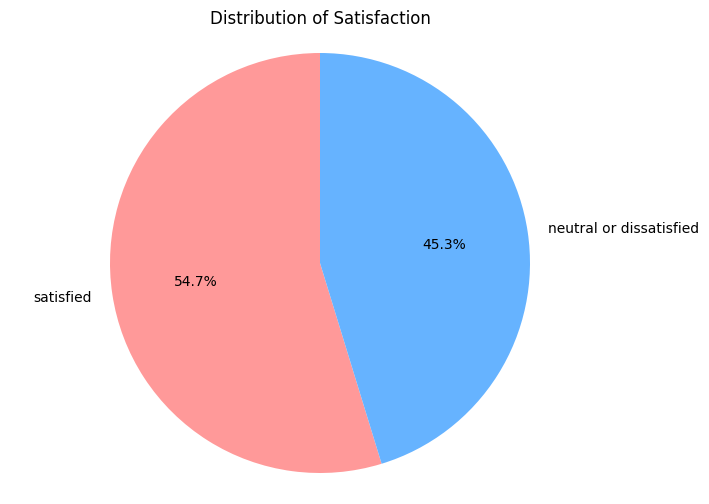

In [18]:
plt.figure(figsize=(8, 6))

satisfaction_counts = df['satisfaction'].value_counts()
plt.pie(satisfaction_counts.values, 
        labels=satisfaction_counts.index, 
        autopct='%1.1f%%',
        startangle=90,
        colors=['#ff9999', '#66b3ff'])

plt.title('Distribution of Satisfaction')
plt.axis('equal')
plt.show()


#### Qualitative Variables

C:\Users\HP\AppData\Local\Temp\ipykernel_19260\3343469688.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=(1.05,0.5))
C:\Users\HP\AppData\Local\Temp\ipykernel_19260\3343469688.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6,3), dpi=100)


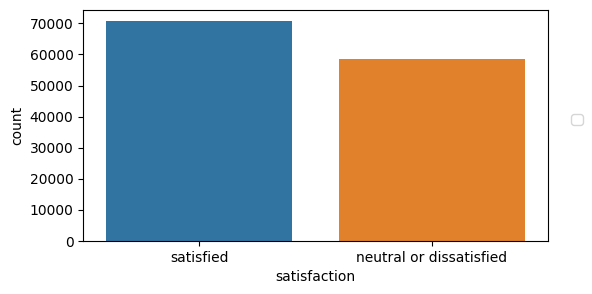

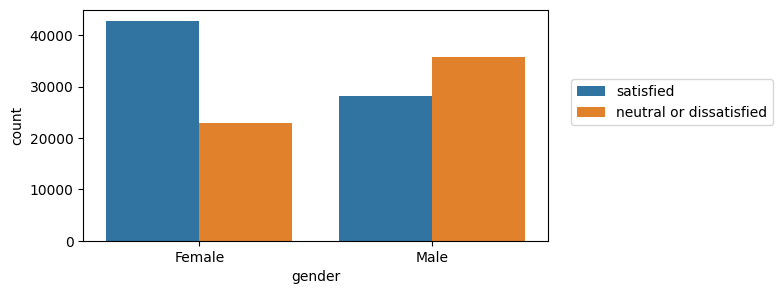

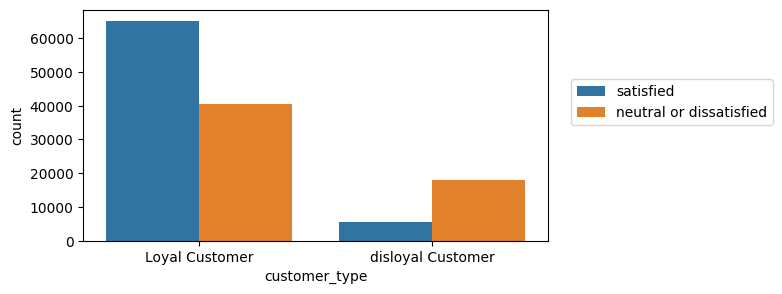

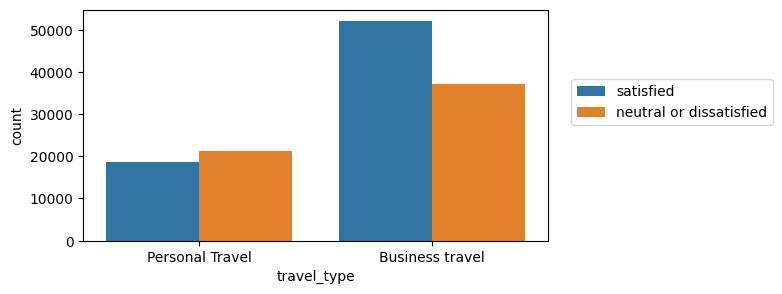

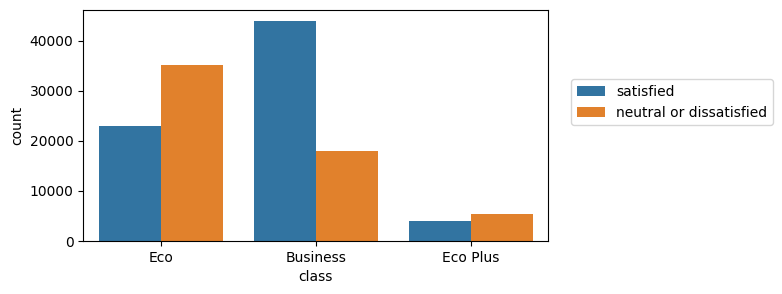

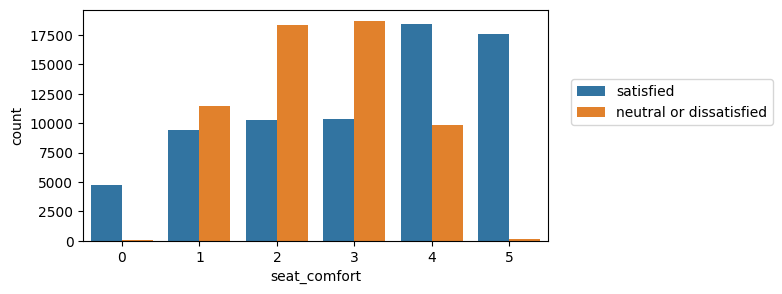

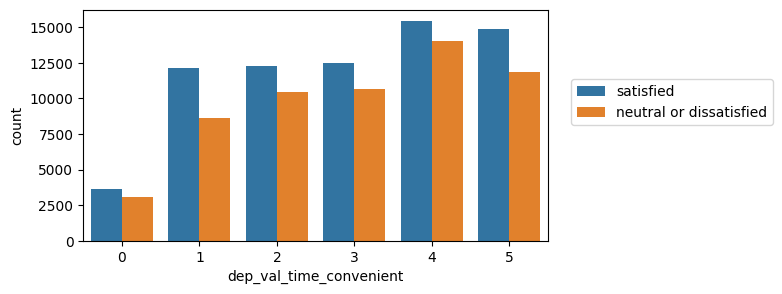

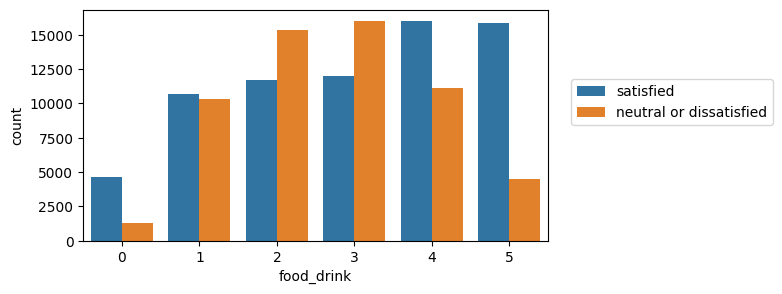

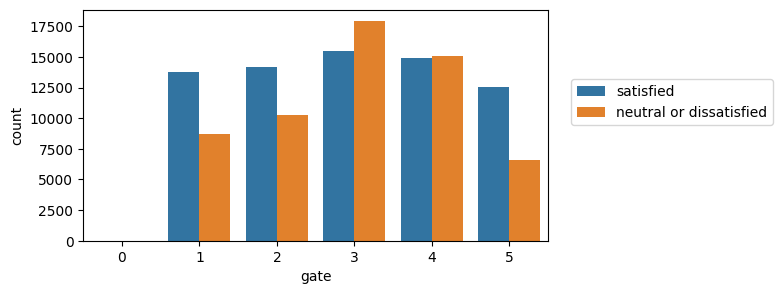

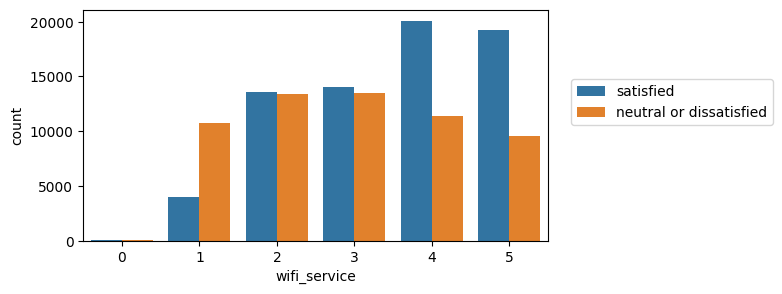

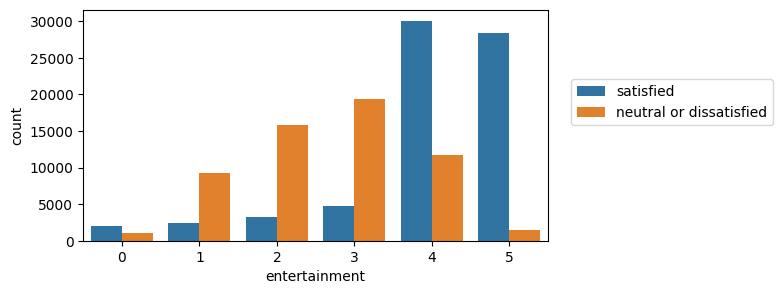

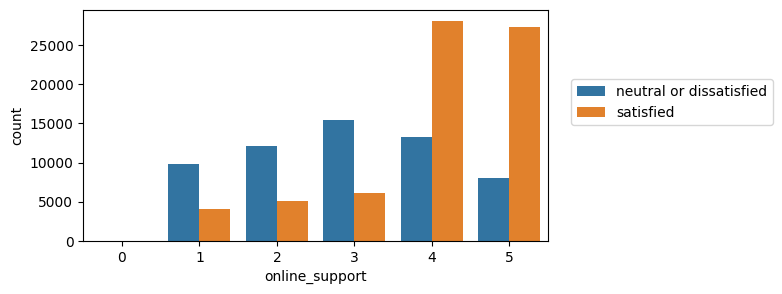

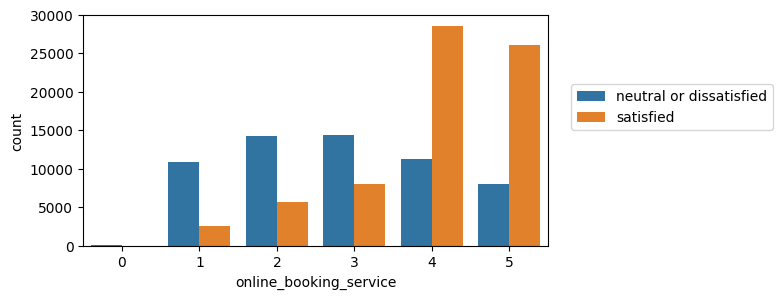

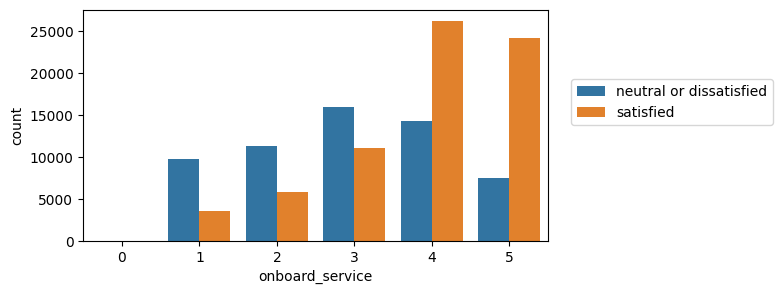

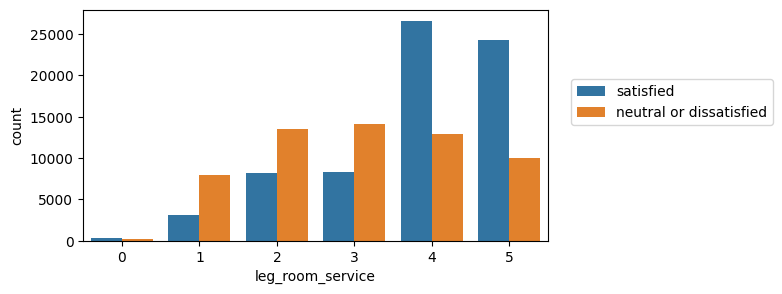

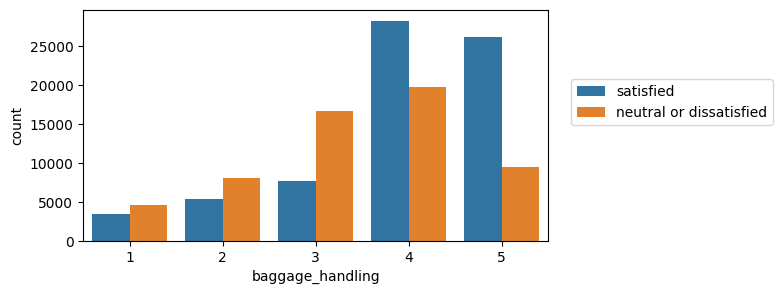

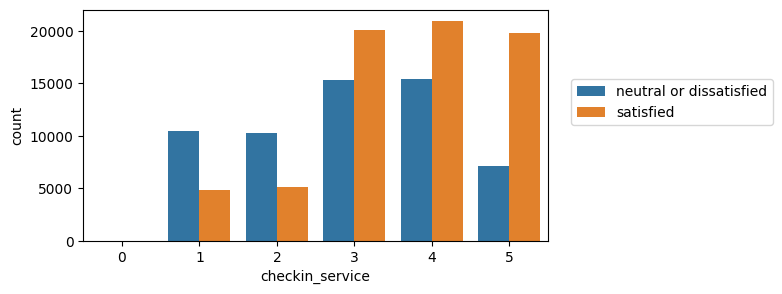

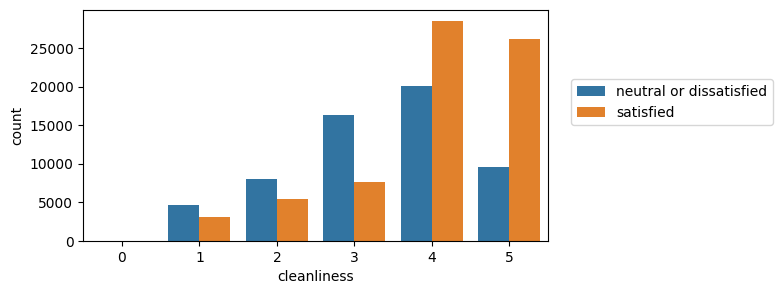

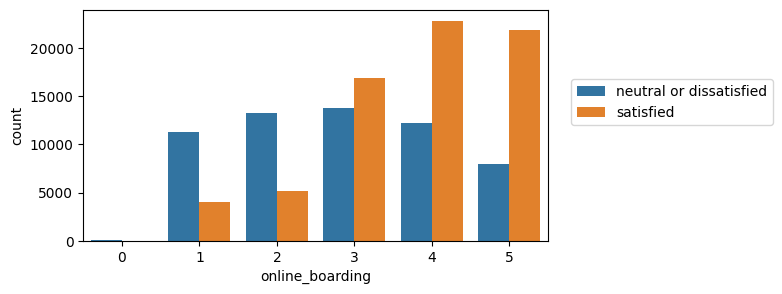

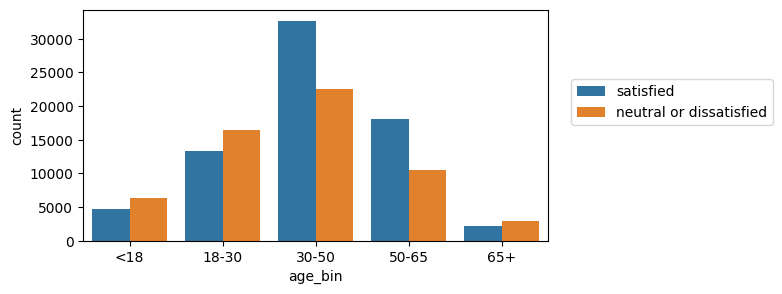

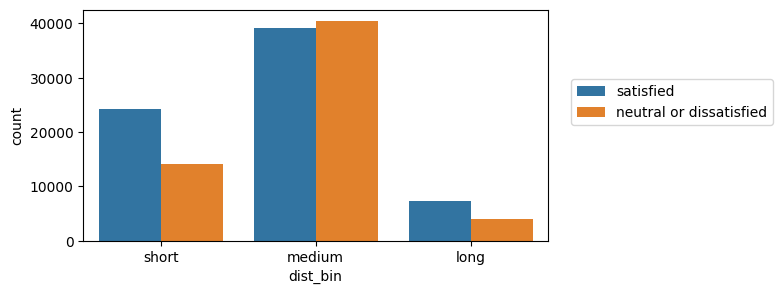

In [19]:
for col in df_qualitative: 
    plt.figure(figsize=(6,3), dpi=100) 
    sns.countplot(data=df,x=col,hue ='satisfaction') 
    plt.legend(loc=(1.05,0.5))

In [20]:
for cols in df_qualitative:
    cat_group = df.groupby(cols)['satisfaction'].describe()
    percent = 100 * (cat_group['freq'] / cat_group['count'])
    
    print('\n' + '*'*65)
    print(f"Insights from '{cols}' data")
    
    for i in range(len(cat_group)):
        print(f"{round(percent.iloc[i], 2)}% from {percent.index[i]} are {cat_group['top'].iloc[i]}")
    
    print('*'*65)


*****************************************************************
Insights from 'satisfaction' data
100.0% from neutral or dissatisfied are neutral or dissatisfied
100.0% from satisfied are satisfied
*****************************************************************

*****************************************************************
Insights from 'gender' data
65.14% from Female are satisfied
55.97% from Male are neutral or dissatisfied
*****************************************************************

*****************************************************************
Insights from 'customer_type' data
61.64% from Loyal Customer are satisfied
76.01% from disloyal Customer are neutral or dissatisfied
*****************************************************************

*****************************************************************
Insights from 'travel_type' data
58.37% from Business travel are satisfied
53.36% from Personal Travel are neutral or dissatisfied
*****************************

C:\Users\HP\AppData\Local\Temp\ipykernel_19260\3758267580.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_group = df.groupby(cols)['satisfaction'].describe()
C:\Users\HP\AppData\Local\Temp\ipykernel_19260\3758267580.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_group = df.groupby(cols)['satisfaction'].describe()


#### Quantitative Variables

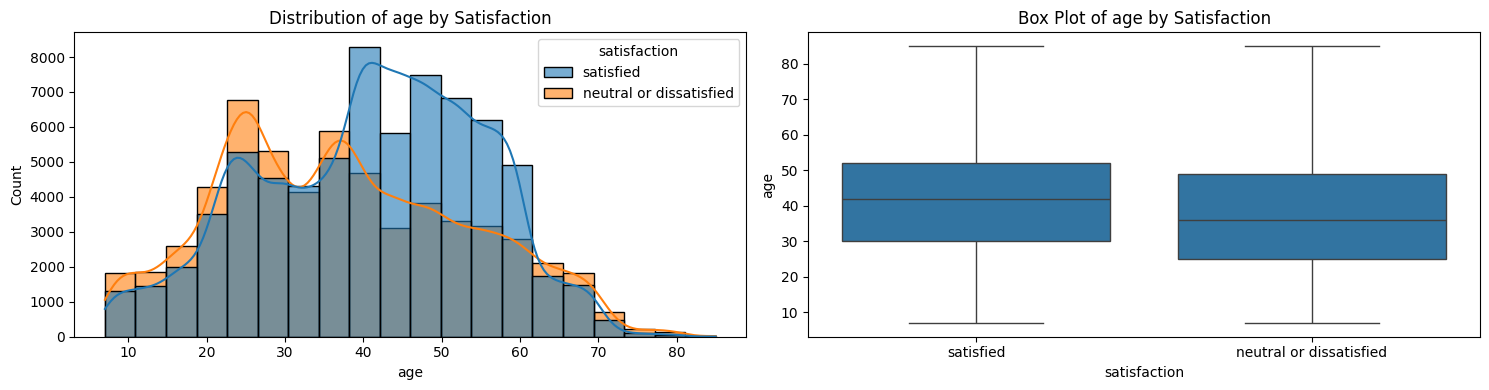

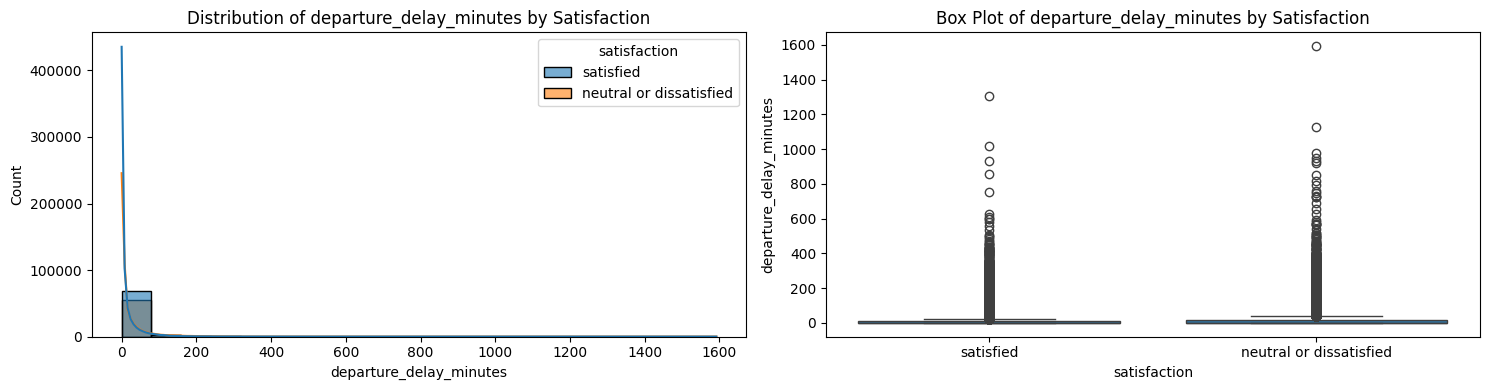

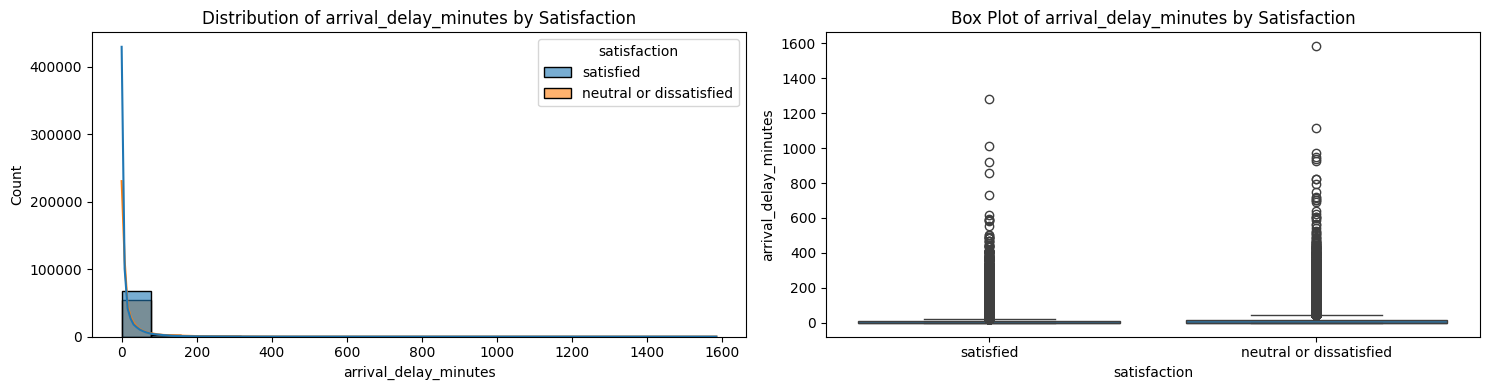

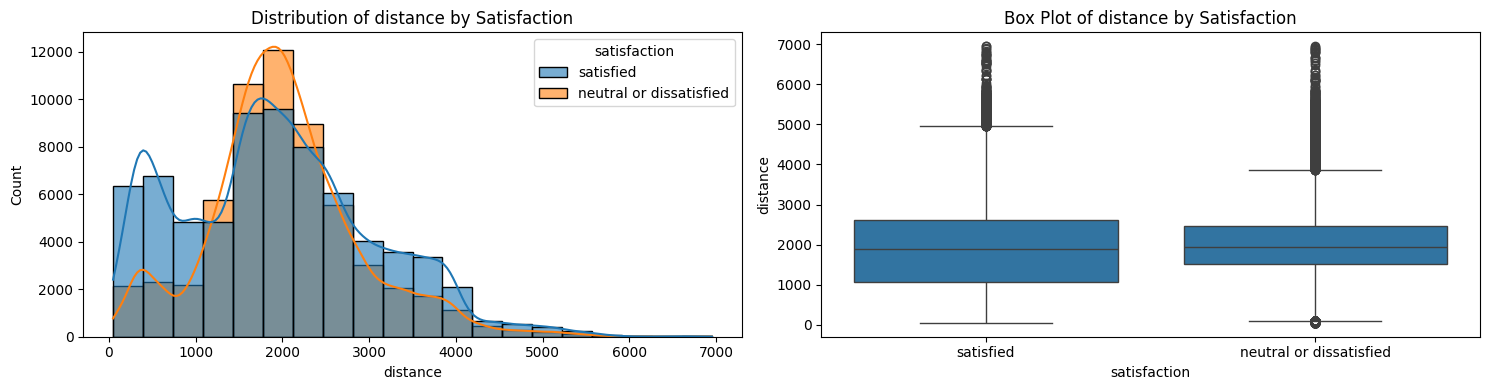

In [21]:
# Plot continuous features divided by satisfaction
for col in df_quantitative:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
   
    # Plot 1: Overlapping histograms
    sns.histplot(data=df, x=col, hue='satisfaction', kde=True, bins=20, alpha=0.6, ax=axes[0])
    axes[0].set_title(f"Distribution of {col} by Satisfaction")
      
    # Plot 2: Box plots
    sns.boxplot(data=df, x='satisfaction', y=col, ax=axes[1])
    axes[1].set_title(f"Box Plot of {col} by Satisfaction")
   
    plt.tight_layout()
    plt.show()

##### Analysis of Passenger Class

In [22]:
selected_features = ['age','satisfaction','gender','travel_type', 'customer_type','seat_comfort',
                     'food_drink','wifi_service','entertainment','online_support',
                     'online_booking_service','onboard_service','leg_room_service',
                     'baggage_handling','checkin_service','cleanliness','online_boarding', 'age_bin', 'dep_val_time_convenient', 'gate', 'dist_bin']

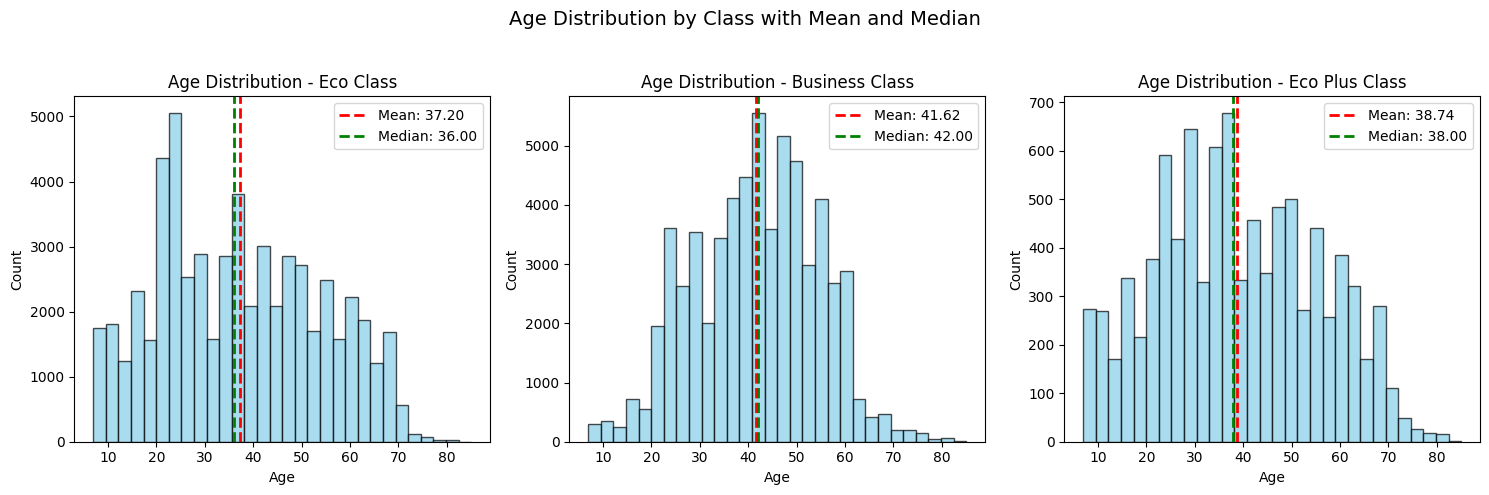

In [23]:
# Get unique classes
classes = df['class'].unique()

# Plot age histograms by class with mean and median
plt.figure(figsize=(15, 5), dpi=100)
classes = df['class'].unique()

for idx, class_type in enumerate(classes, 1):
    plt.subplot(1, 3, idx)
    age_data = df[df['class'] == class_type]['age']
    
    plt.hist(age_data, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    
    mean_age = age_data.mean()
    median_age = age_data.median()
    
    plt.axvline(mean_age, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_age:.2f}')
    plt.axvline(median_age, color='green', linestyle='--', linewidth=2, label=f'Median: {median_age:.2f}')
    
    plt.title(f'Age Distribution - {class_type} Class')
    plt.xlabel('Age')
    plt.ylabel('Count')
    plt.legend()

plt.suptitle('Age Distribution by Class with Mean and Median', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_19260\4135273661.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Satisfaction', loc='upper right', fontsize=8)
C:\Users\HP\AppData\Local\Temp\ipykernel_19260\4135273661.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Satisfaction', loc='upper right', fontsize=8)
C:\Users\HP\AppData\Local\Temp\ipykernel_19260\4135273661.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Satisfaction', loc='upper right', fontsize=8)


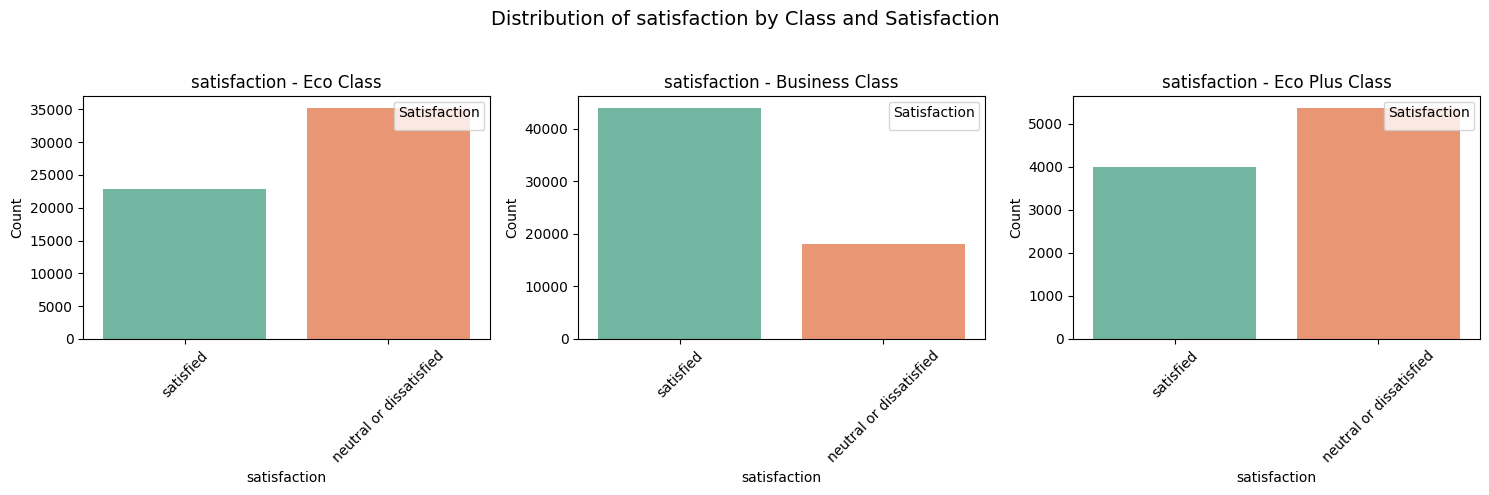

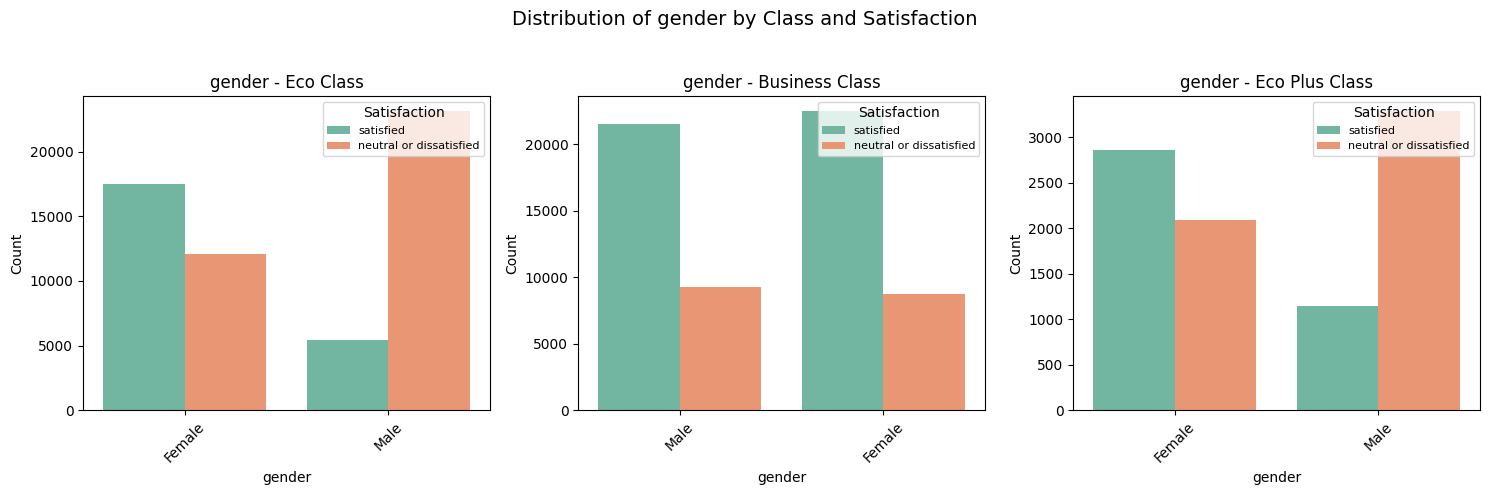

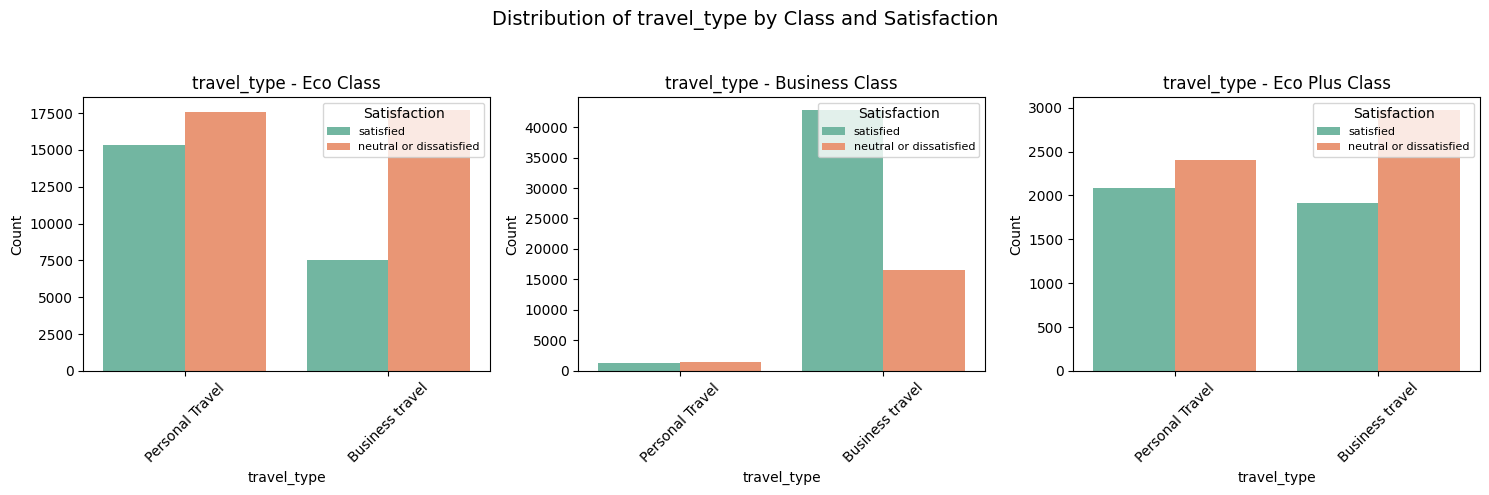

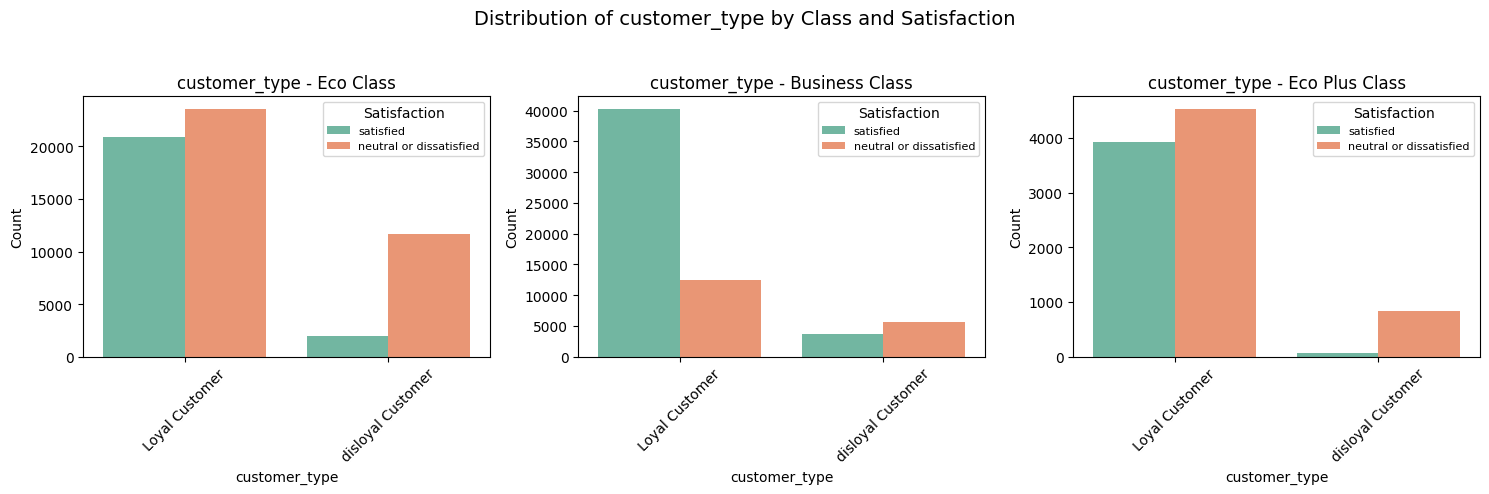

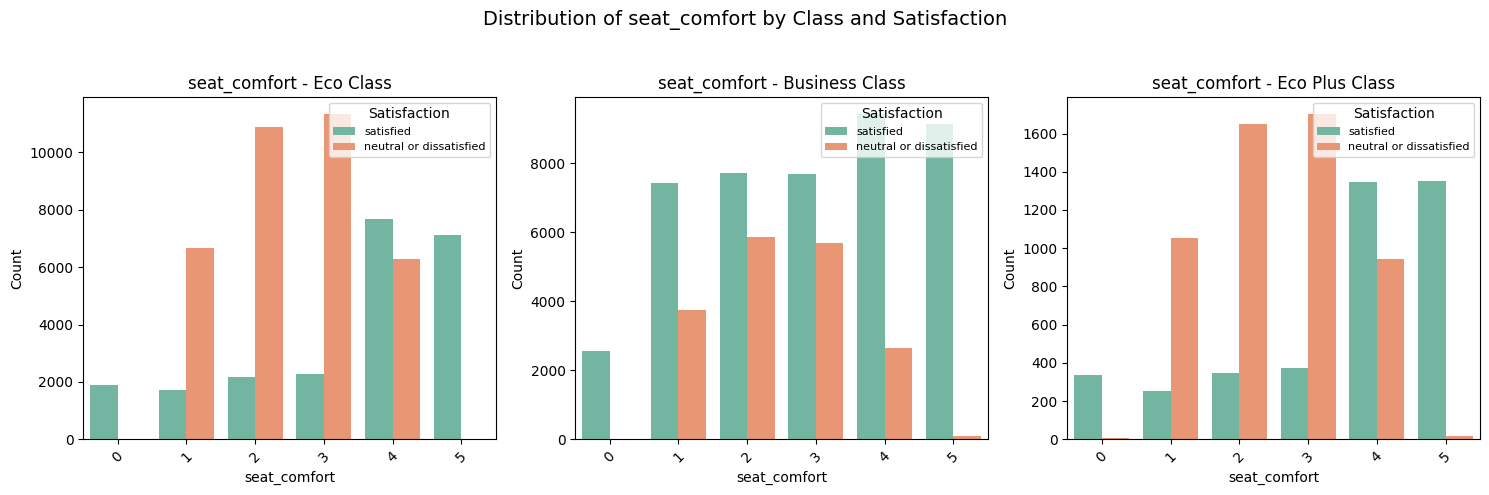

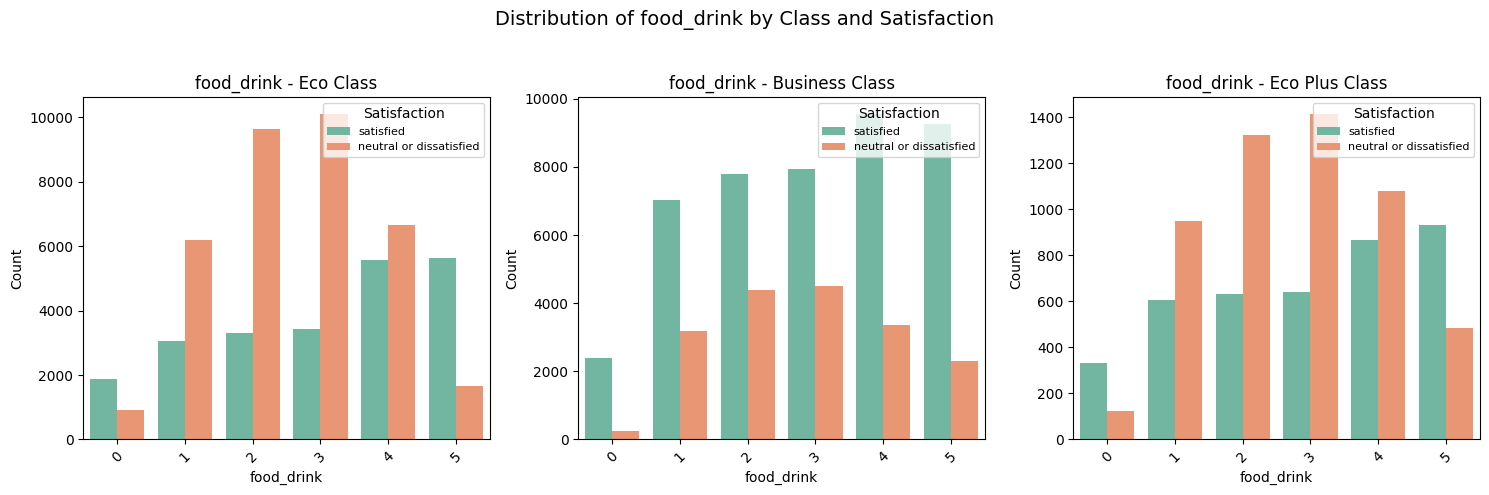

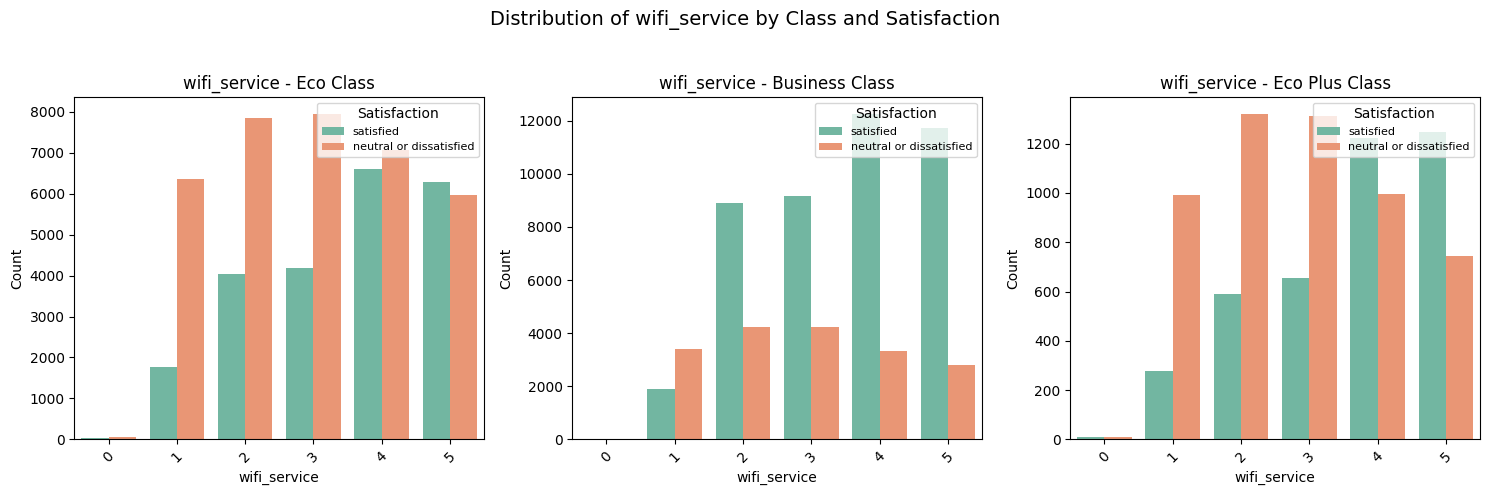

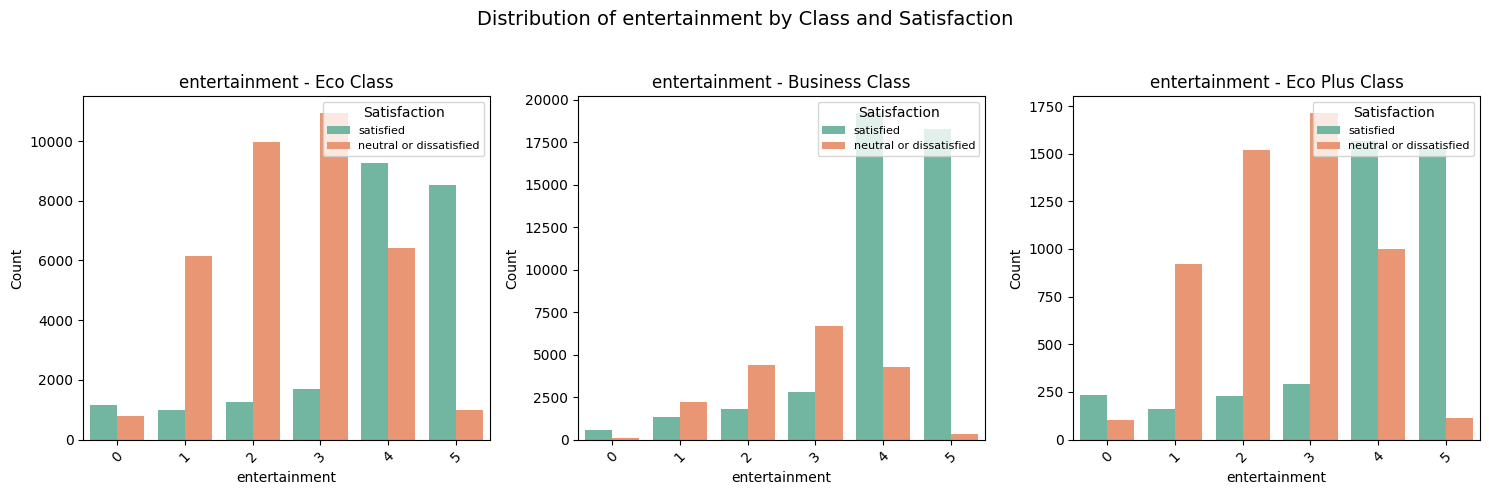

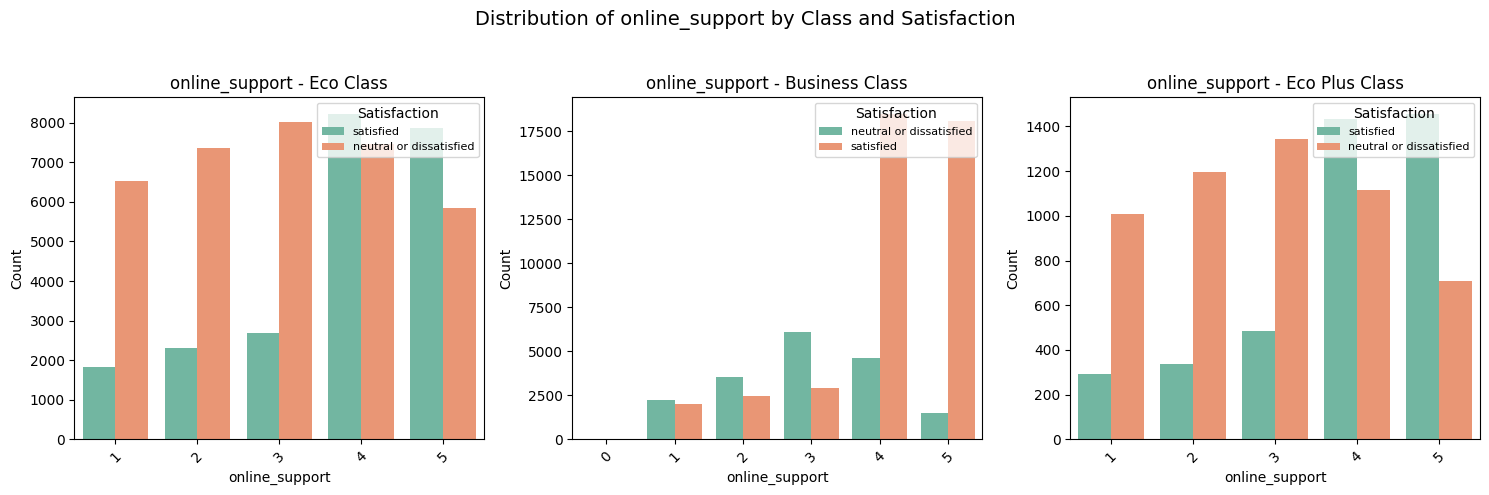

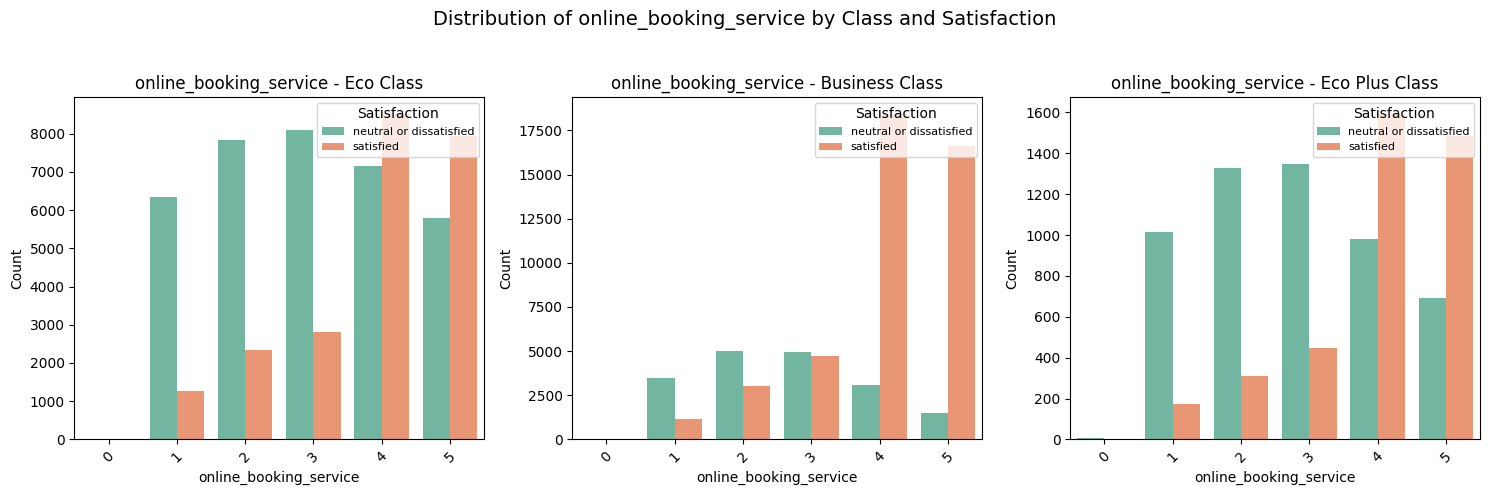

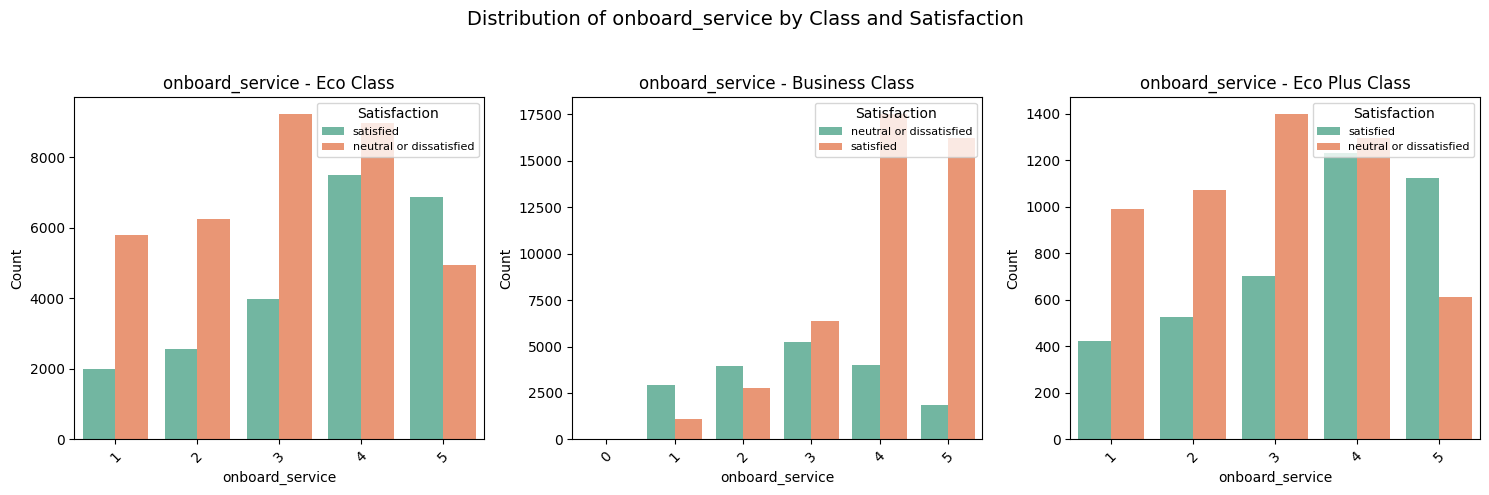

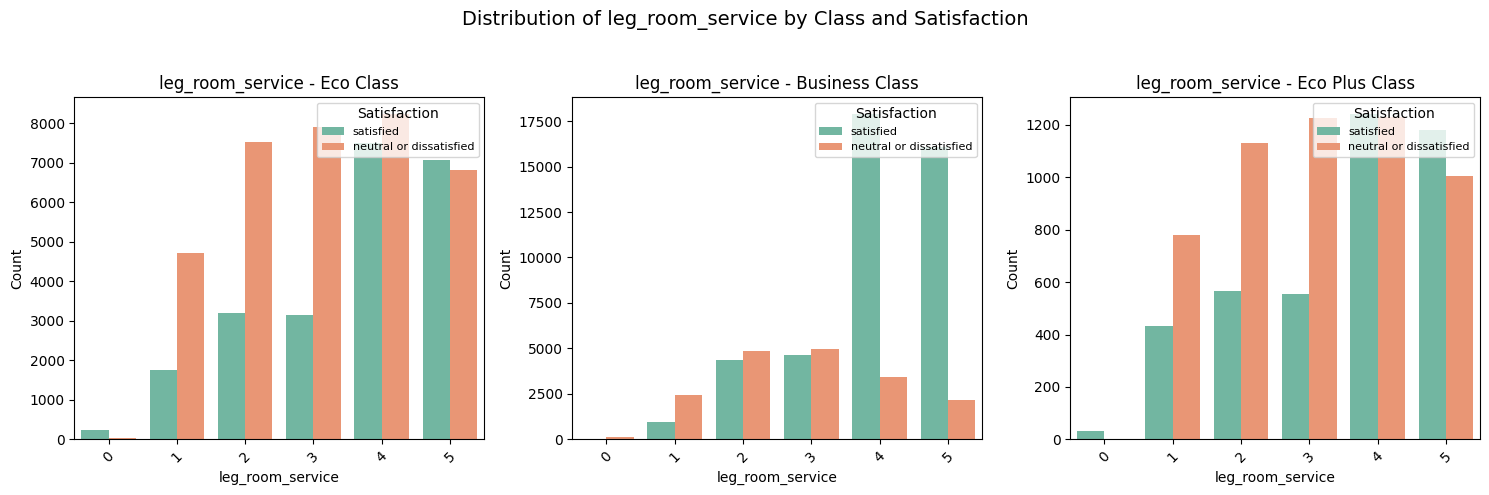

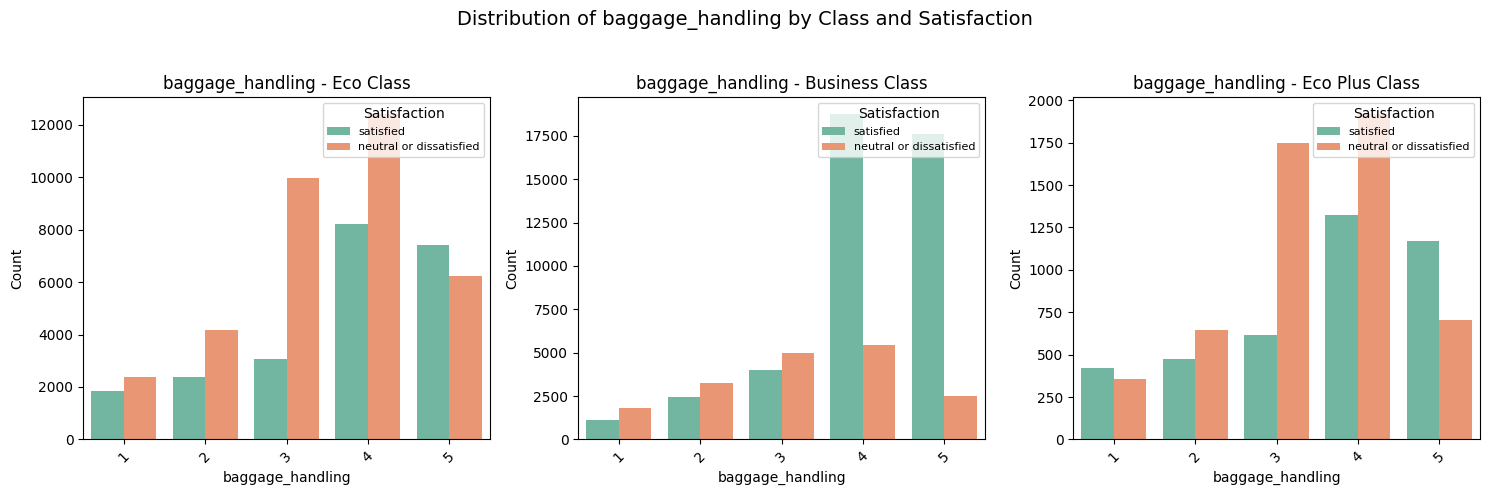

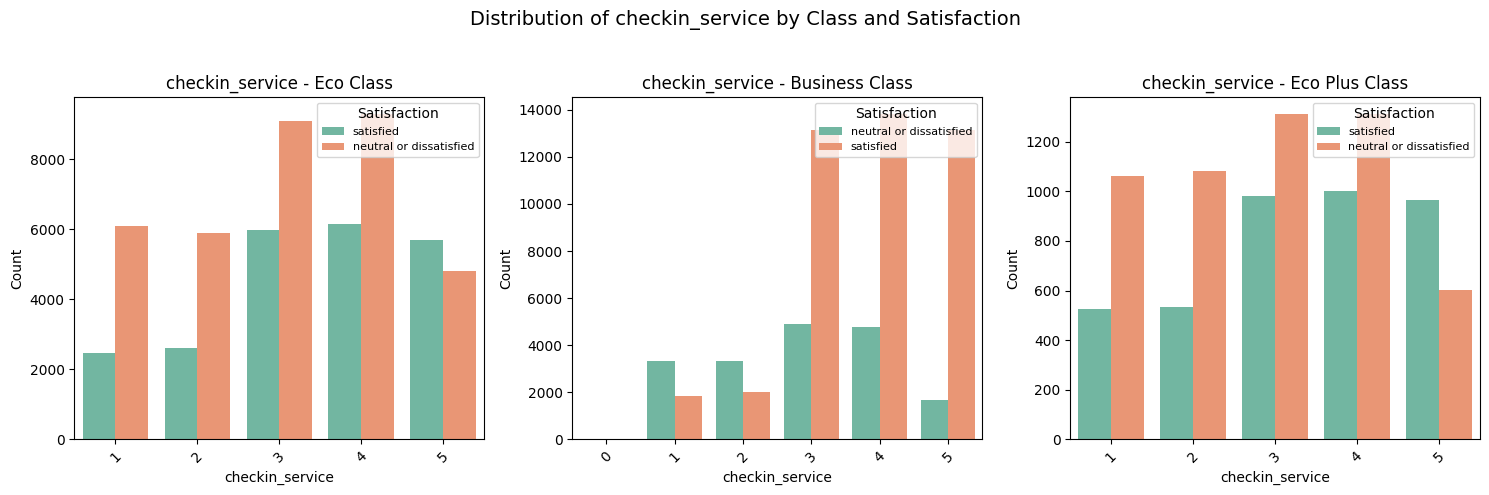

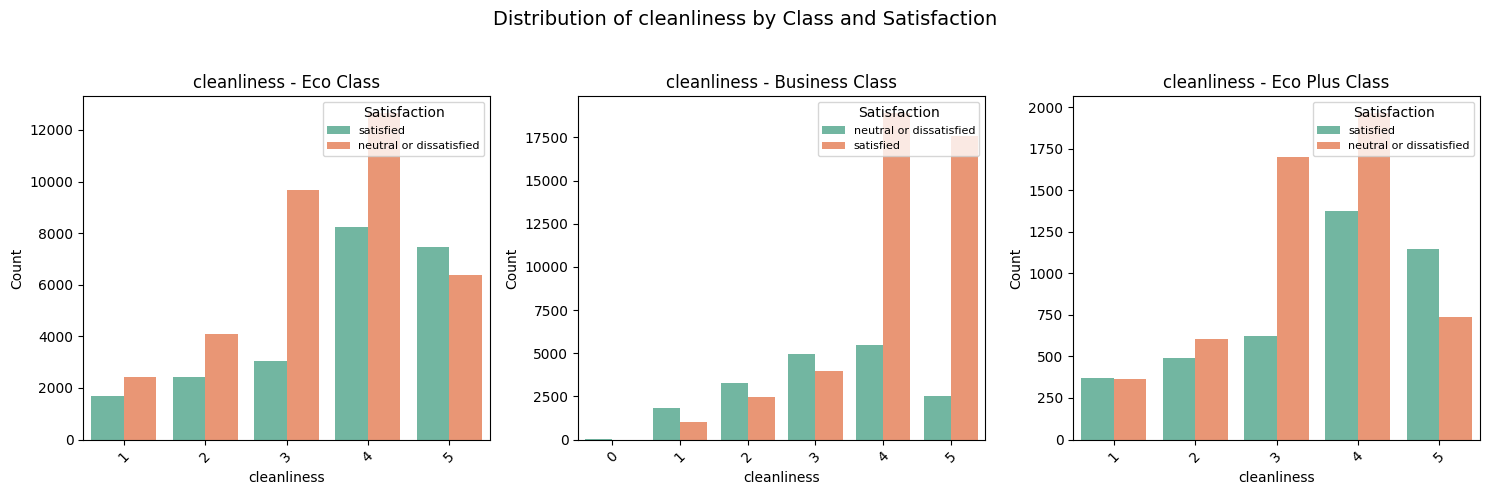

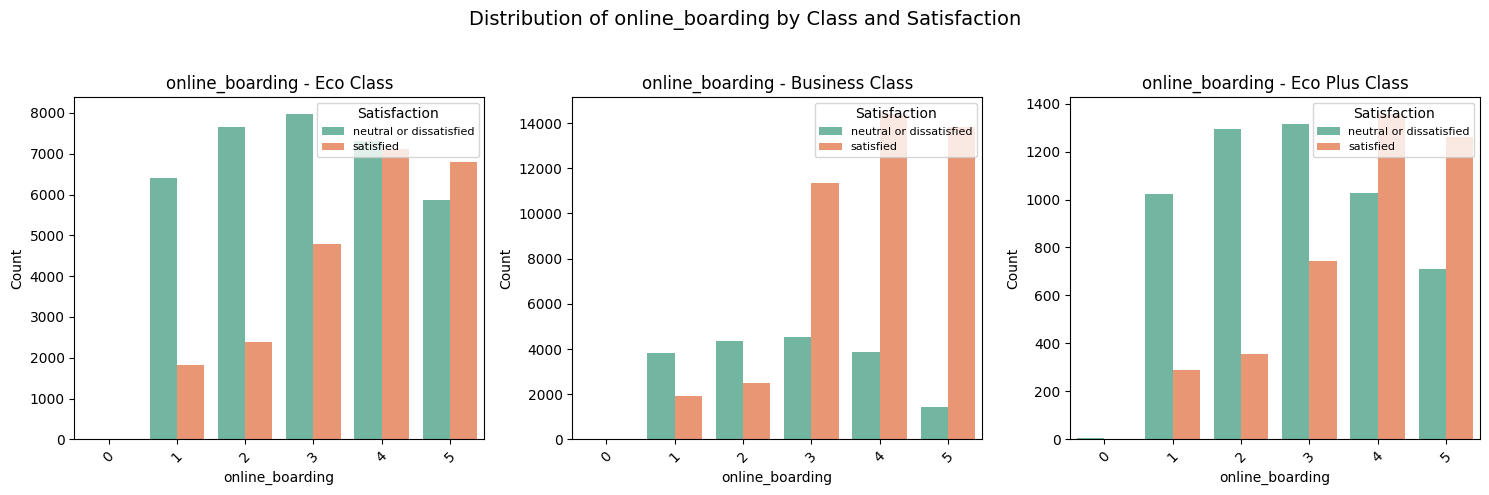

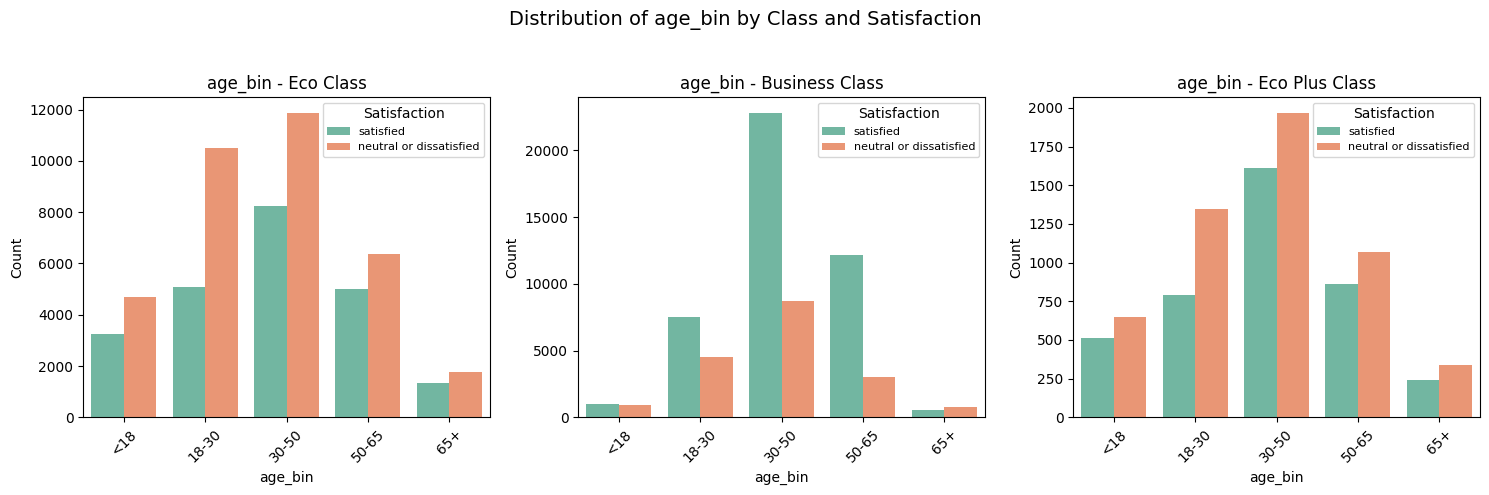

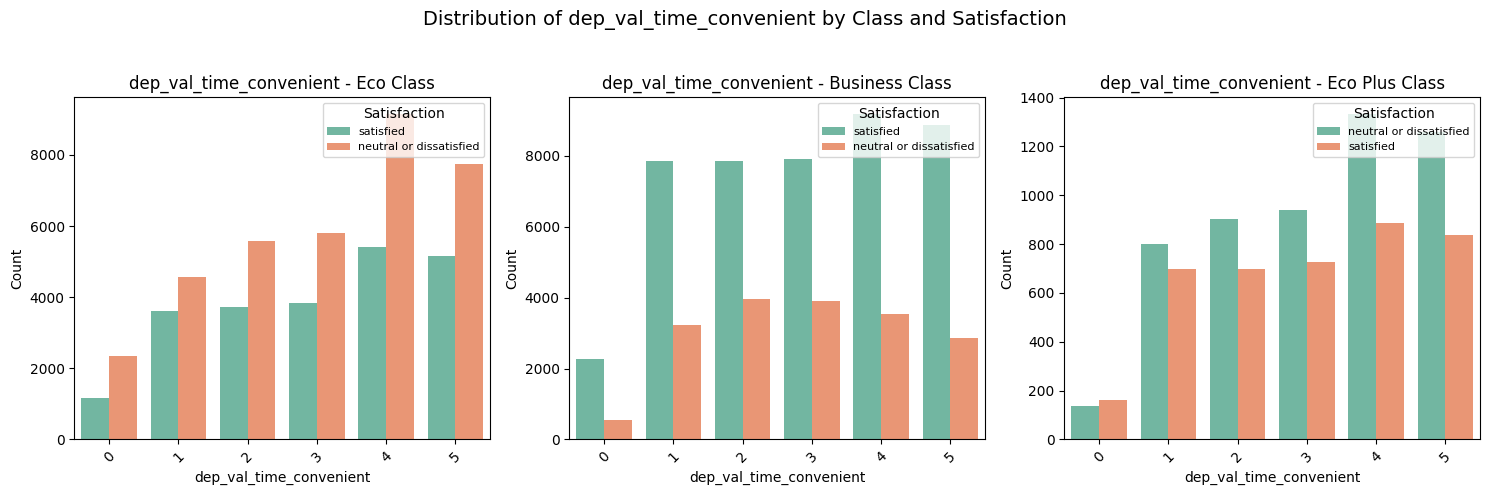

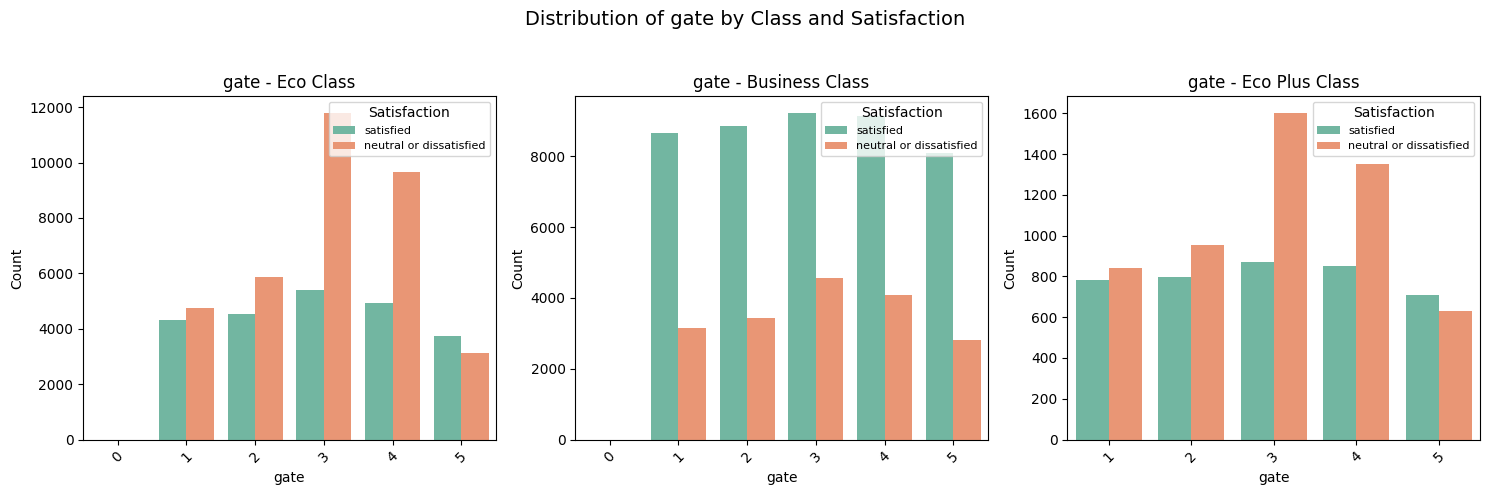

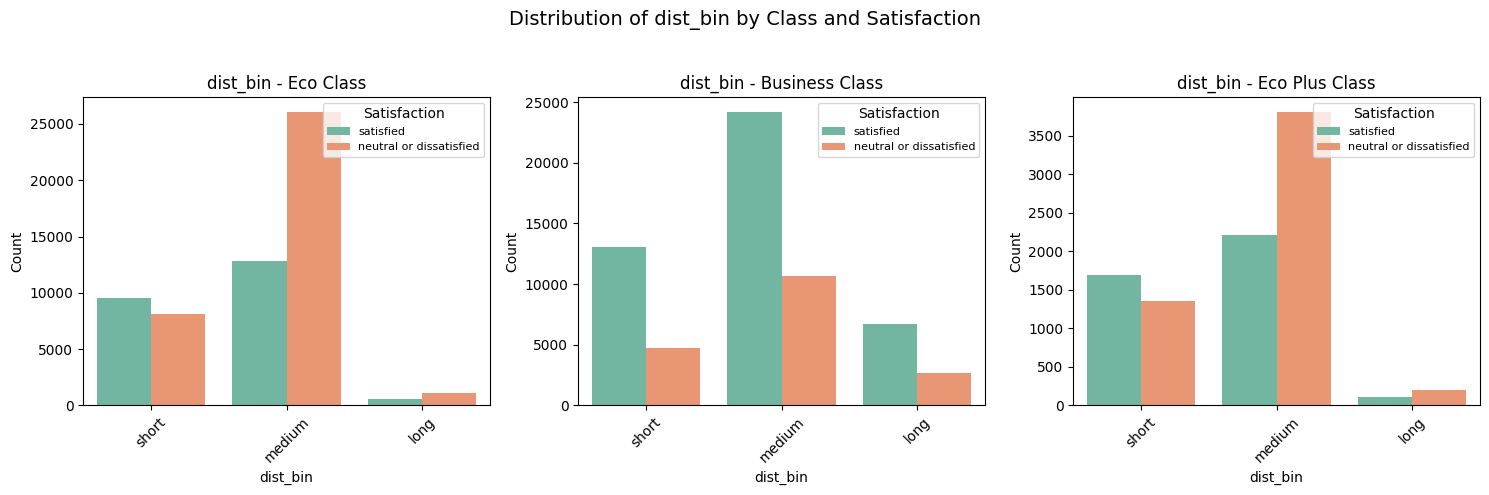

In [24]:
# Plot comparisons for each feature
for col in selected_features:
    if col != 'age':  # skip age histogram
        plt.figure(figsize=(15, 5), dpi=100)
       
        # Create subplots for each class
        for idx, class_type in enumerate(classes, 1):
            plt.subplot(1, 3, idx)
            sns.countplot(data=df[df['class'] == class_type],
                          x=col, hue='satisfaction', palette='Set2')
            plt.title(f'{col} - {class_type} Class')
            plt.xlabel(col)
            plt.ylabel('Count')
            plt.legend(title='Satisfaction', loc='upper right', fontsize=8)
            plt.xticks(rotation=45)
        
        plt.suptitle(f'Distribution of {col} by Class and Satisfaction', fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

##### Loyal and Disloyal Passengers

In [25]:
loyal_customers = df[df['customer_type'] == 'Loyal Customer']
loyal_customers = loyal_customers[selected_features]

In [26]:
disloyal_customers = df[df['customer_type'] != 'Loyal Customer']
disloyal_customers = disloyal_customers[selected_features]

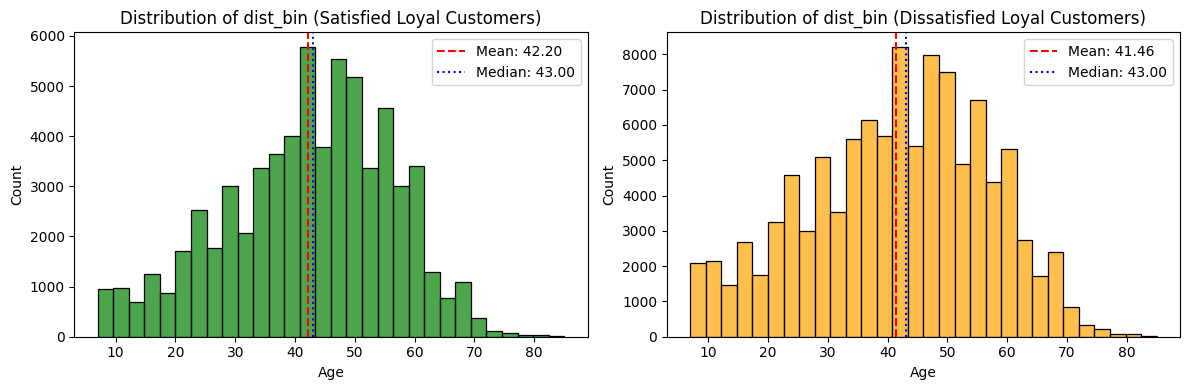

In [27]:
# Separate data for satisfied and dissatisfied loyal customers
satisfied = loyal_customers[loyal_customers['satisfaction'] == 'satisfied']
dissatisfied = loyal_customers[loyal_customers['satisfaction'] != 'dissatisfied']

# Create two subplots side by side
plt.figure(figsize=(12, 4), dpi=100)

# --- Plot for satisfied loyal customers ---
plt.subplot(1, 2, 1)
sns.histplot(satisfied['age'], bins=30, color='green', kde=False, alpha=0.7)
mean_val = satisfied['age'].mean()
median_val = satisfied['age'].median()
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='blue', linestyle=':', label=f'Median: {median_val:.2f}')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title(f'Distribution of {col} (Satisfied Loyal Customers)')
plt.legend()

# --- Plot for dissatisfied loyal customers ---
plt.subplot(1, 2, 2)
sns.histplot(dissatisfied['age'], bins=30, color='orange', kde=False, alpha=0.7)
mean_val = dissatisfied['age'].mean()
median_val = dissatisfied['age'].median()
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='blue', linestyle=':', label=f'Median: {median_val:.2f}')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title(f'Distribution of {col} (Dissatisfied Loyal Customers)')
plt.legend()

plt.tight_layout()
plt.show()

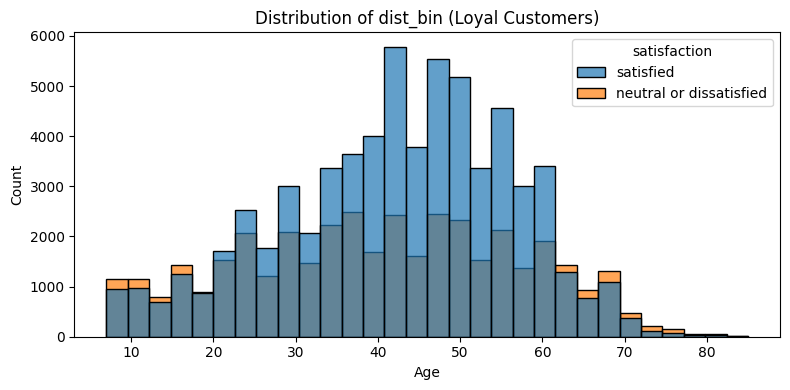

In [28]:
plt.figure(figsize=(8, 4), dpi=100) 
sns.histplot(data=loyal_customers, x='age', hue='satisfaction', bins=30, kde=False, alpha=0.7) 
plt.xlabel('Age') 
plt.ylabel('Count') 
plt.title(f'Distribution of {col} (Loyal Customers)') 
plt.tight_layout() 
plt.show()

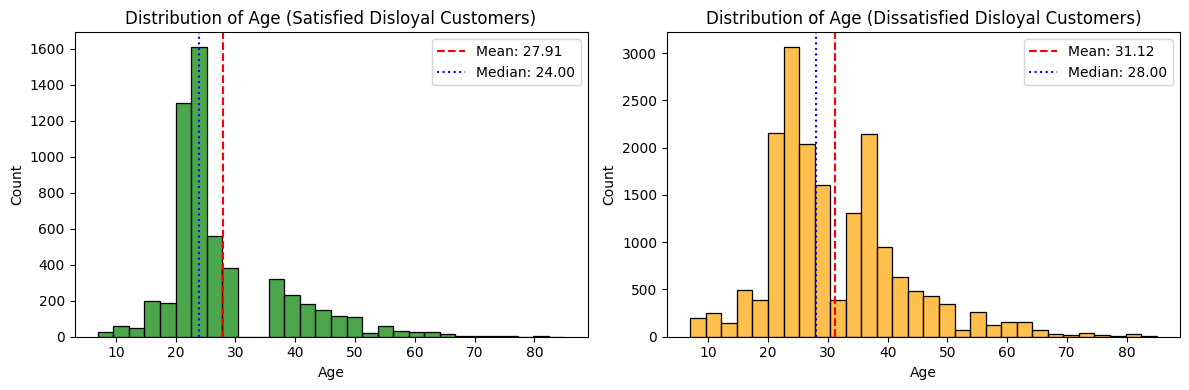

In [29]:
# Separate data for satisfied and dissatisfied customers
satisfied = disloyal_customers[disloyal_customers['satisfaction'] == 'satisfied']
dissatisfied = disloyal_customers[disloyal_customers['satisfaction'] != 'satisfied']

# Create two subplots side by side
plt.figure(figsize=(12, 4), dpi=100)

# --- Plot for satisfied customers ---
plt.subplot(1, 2, 1)
sns.histplot(satisfied['age'], bins=30, color='green', kde=False, alpha=0.7)
mean_val = satisfied['age'].mean()
median_val = satisfied['age'].median()
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='blue', linestyle=':', label=f'Median: {median_val:.2f}')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Distribution of Age (Satisfied Disloyal Customers)')
plt.legend()

# --- Plot for dissatisfied customers ---
plt.subplot(1, 2, 2)
sns.histplot(dissatisfied['age'], bins=30, color='orange', kde=False, alpha=0.7)
mean_val = dissatisfied['age'].mean()
median_val = dissatisfied['age'].median()
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='blue', linestyle=':', label=f'Median: {median_val:.2f}')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Distribution of Age (Dissatisfied Disloyal Customers)')
plt.legend()

plt.tight_layout()
plt.show()

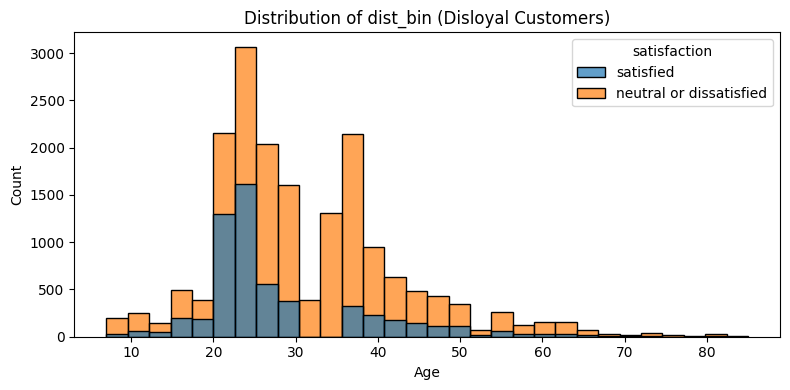

In [30]:
plt.figure(figsize=(8, 4), dpi=100) 
sns.histplot(data=disloyal_customers, x='age', hue='satisfaction', bins=30, kde=False, alpha=0.7) 
plt.xlabel('Age') 
plt.ylabel('Count') 
plt.title(f'Distribution of {col} (Disloyal Customers)') 
plt.tight_layout() 
plt.show()

#### Satisfaction of loyal customers

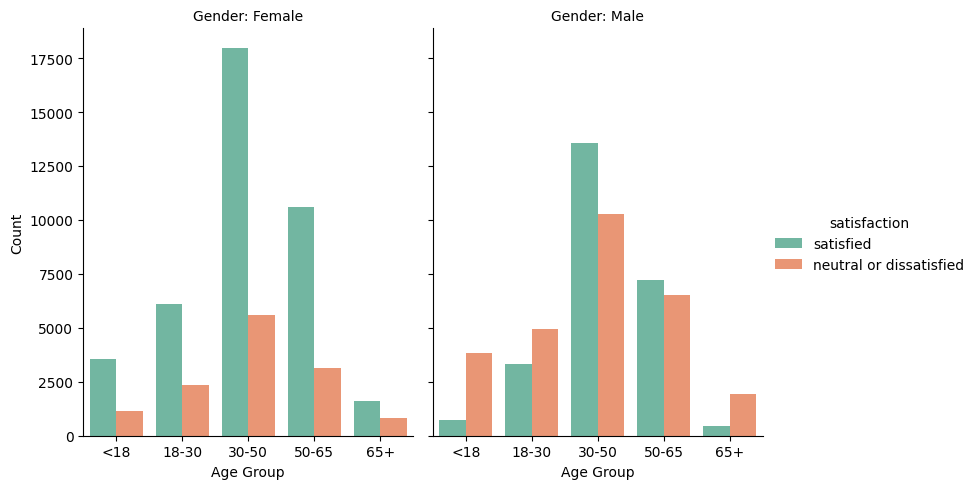

In [31]:
g = sns.catplot(
    data=loyal_customers,
    x="age_bin", hue="satisfaction", col="gender",
    kind="count", height=5, aspect=0.8, palette="Set2"
)
g.set_titles("Gender: {col_name}")
g.set_axis_labels("Age Group", "Count")

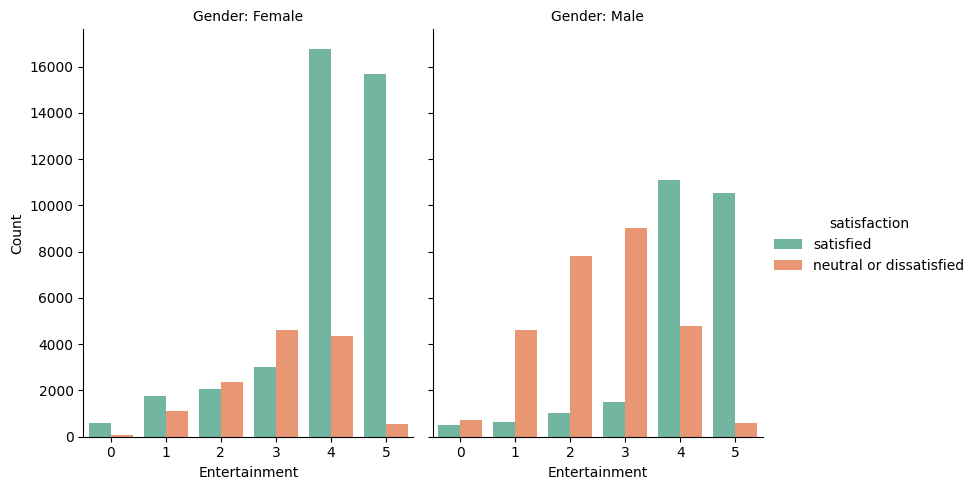

In [32]:
e = sns.catplot(
    data=loyal_customers,
    x="entertainment", hue="satisfaction", col="gender",
    kind="count", height=5, aspect=0.8, palette="Set2"
)
e.set_titles("Gender: {col_name}")
e.set_axis_labels("Entertainment", "Count")

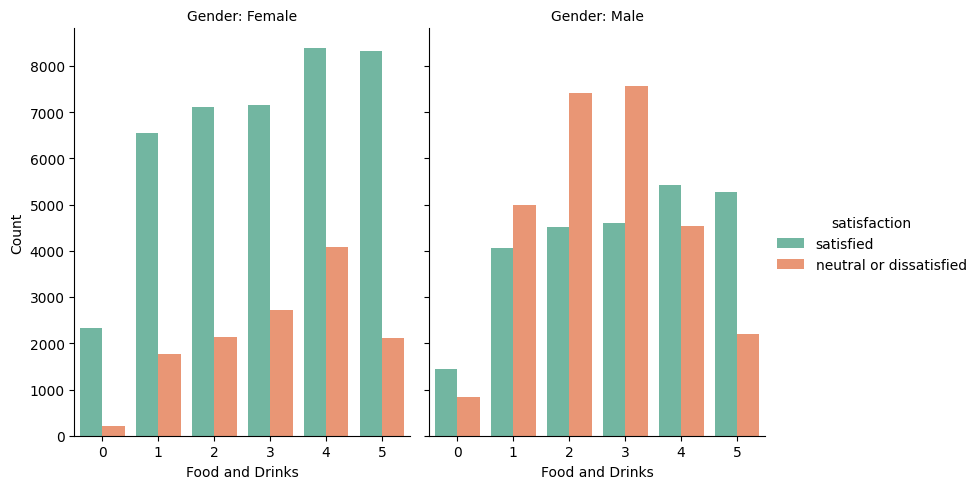

In [33]:
f= sns.catplot(
    data=loyal_customers,
    x='food_drink', hue="satisfaction", col="gender",
    kind="count", height=5, aspect=0.8, palette="Set2"
)
f.set_titles("Gender: {col_name}")
f.set_axis_labels("Food and Drinks", "Count")

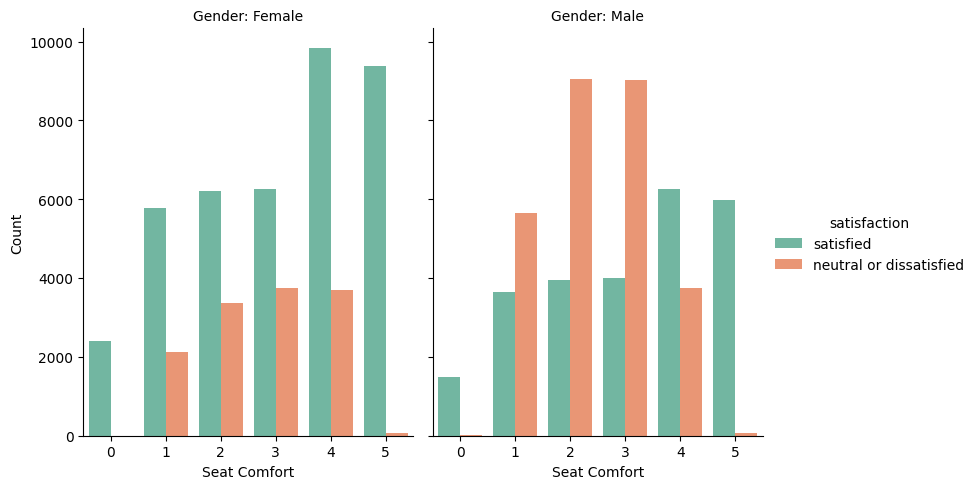

In [34]:
s = sns.catplot(
    data=loyal_customers,
    x='seat_comfort', hue="satisfaction", col="gender",
    kind="count", height=5, aspect=0.8, palette="Set2"
)
s.set_titles("Gender: {col_name}")
s.set_axis_labels("Seat Comfort", "Count")

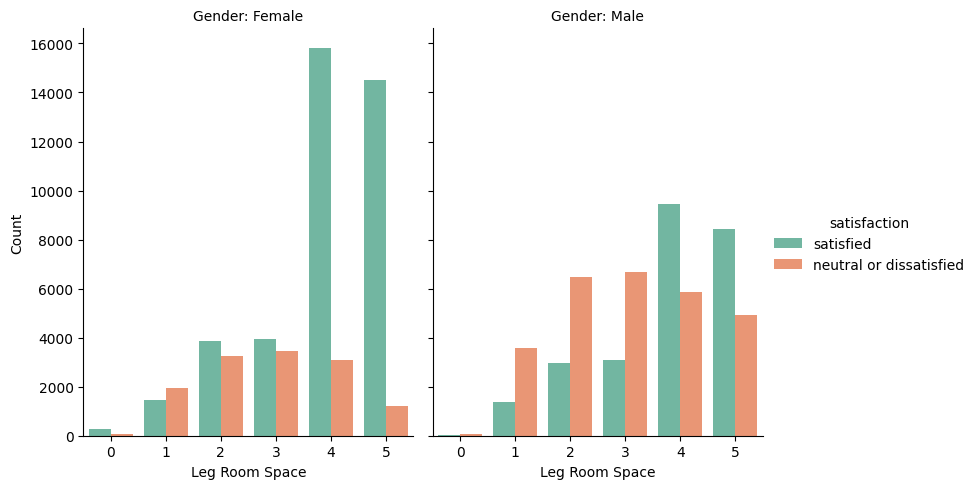

In [35]:
l = sns.catplot(
    data=loyal_customers,
    x='leg_room_service', hue="satisfaction", col="gender",
    kind="count", height=5, aspect=0.8, palette="Set2"
)
l.set_titles("Gender: {col_name}")
l.set_axis_labels("Leg Room Space", "Count")

In [36]:
# encoding categorical variables to numerical variables
mappings = {
    'satisfaction': {'neutral or dissatisfied': 0, 'satisfied': 1},
    'gender': {'Female': 0, 'Male': 1},
    'customer_type': {'Loyal Customer': 0, 'disloyal Customer': 1},
    'travel_type': {'Personal Travel': 0, 'Business travel': 1},
    'class': {'Eco': 0, 'Eco Plus': 1, 'Business': 2},
    'age_bin' : {'<18':1,'18-30':2,'30-50':3,'50-65':4,'65+':5},
    'dist_bin' : {'short': 1, 'medium': 2, 'long': 3}
}

In [37]:
# Apply mappings
for col, mapping in mappings.items():
    df[col] = df[col].map(mapping)

In [38]:
# nominal qualitative variable columns
nominal_columns = ['satisfaction', 'gender', 'customer_type', 'travel_type','class']
df_nominal = df[nominal_columns].copy()

# ordinal qualitative variable columns
ordinal_columns = [col for col in df_qualitative.columns if col not in nominal_columns]
df_ordinal = df[ordinal_columns].copy()

#### Clustering

Hierarchical Clustering with Gower Distance algorithm used becuase this is a mixed dataset (numeric + categorical) and don’t want to predefine the number of clusters

C:\Users\HP\AppData\Local\Temp\ipykernel_19260\623436304.py:10: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(gower_dist, method='average')


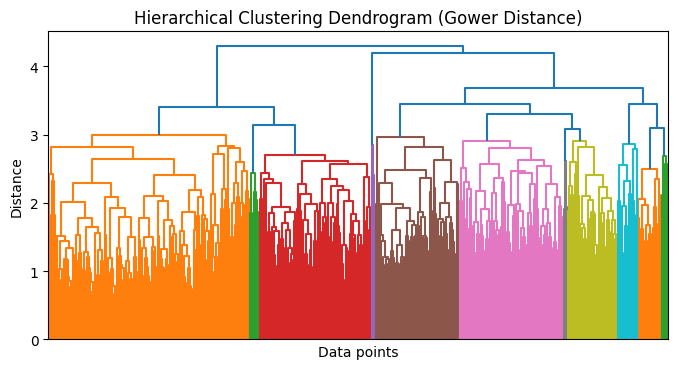

In [39]:
# Sample of the DataFrame
random_rows = df.sample(frac=0.008, random_state=16)
# Drop age_bin from the sampled data
random_rows = random_rows.drop(['age_bin', 'dist_bin'], axis=1, errors='ignore')

# Compute Gower distance
gower_dist = gower.gower_matrix(random_rows)

# Hierarchical clustering
linkage_matrix = sch.linkage(gower_dist, method='average')

# Dendrogram
plt.figure(figsize=(8, 4))
dendro = sch.dendrogram(linkage_matrix, no_labels=True)
plt.title("Hierarchical Clustering Dendrogram (Gower Distance)")
plt.xlabel("Data points")
plt.ylabel("Distance")
plt.show()

In [40]:
# Cut tree at distance threshold or fixed number of clusters
clusters = fcluster(linkage_matrix, t=5, criterion='distance')
random_rows["cluster"] = clusters

# Now summarize by cluster (mode/median for ordinal data)
cluster_summary = random_rows.groupby("cluster").agg(lambda x: x.mode()[0])
print(cluster_summary)

         satisfaction  gender  customer_type  age  travel_type  class  \
cluster                                                                 
1                   1       0              0   25            1      2   

         distance  seat_comfort  dep_val_time_convenient  food_drink  ...  \
cluster                                                               ...   
1            1556             2                        5           3  ...   

         online_support  online_booking_service  onboard_service  \
cluster                                                            
1                     4                       4                4   

         leg_room_service  baggage_handling  checkin_service  cleanliness  \
cluster                                                                     
1                       4                 4                3            4   

         online_boarding  departure_delay_minutes  arrival_delay_minutes  
cluster                             

 ##### one homogeneous cluster
 This cluster describes a satisfied business-class loyal customer (female, ~25 years old). Their main strengths: on-time flights, convenience of departure time, online services, cleanliness. Weak spot: seat comfort (rated low at 2/5).

##### Correlation

In [41]:
corr_mat = df_quantitative.corr()
corr_mat

,age,departure_delay_minutes,arrival_delay_minutes,distance
age,1.000000,-0.009263,-0.011248,-0.249438
departure_delay_minutes,-0.009263,1.000000,0.965291,0.111608
arrival_delay_minutes,-0.011248,0.965291,1.000000,0.110103
distance,-0.249438,0.111608,0.110103,1.000000


##### correlation heatmap

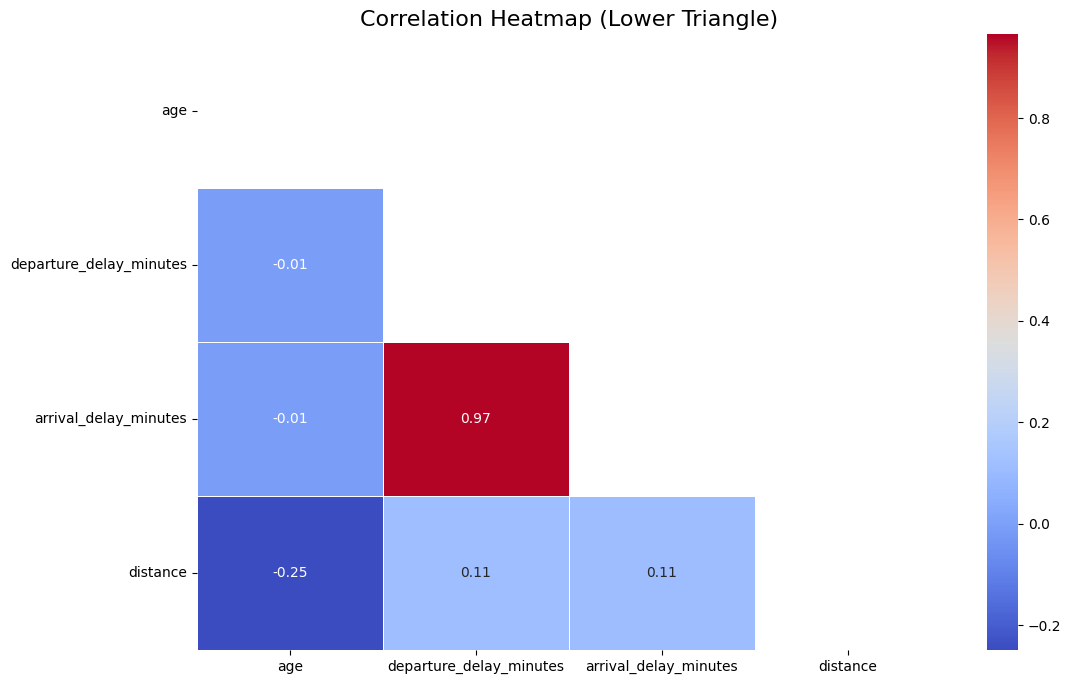

In [42]:
# Mask upper triangle
mask = np.triu(np.ones_like(corr_mat, dtype=bool))

plt.figure(figsize=(12,8))
sns.heatmap(corr_mat, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Lower Triangle)", fontsize=16)
plt.show()

From the results of the plot above, it can be seen that age and gate location do not significantly affect flight satisfaction. Gender and corresponding arrival/departure times also do not provide as much information as in the previous plot. Therefore, these features will be removed

<Axes: xlabel='arrival_delay_minutes', ylabel='departure_delay_minutes'>

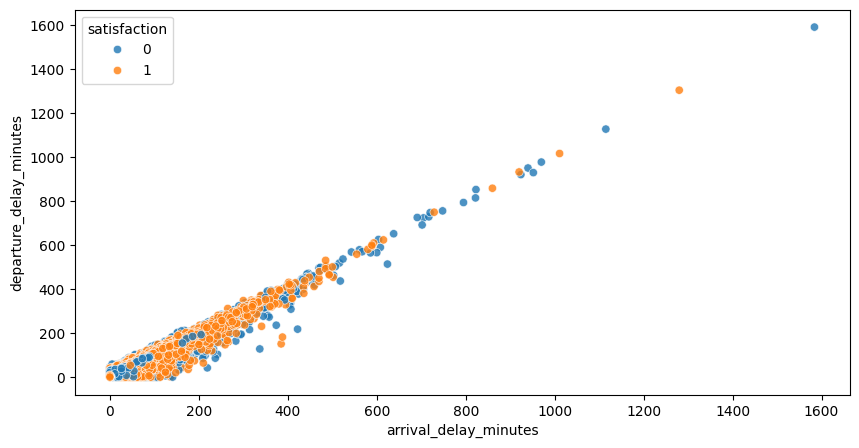

In [43]:
plt.figure(figsize=(10,5), dpi=100)
sns.scatterplot(data=df,x='arrival_delay_minutes',y='departure_delay_minutes',hue='satisfaction', alpha=0.8)

##### D’Agostino and Pearson’s Normality Test (since dataset is larger)

In [44]:
age_group1 = df[df['satisfaction'] == 1]['age']
age_group2 = df[df['satisfaction'] == 0]['age']

stat1, p1 = normaltest(age_group1)
stat2, p2 = normaltest(age_group2)

print("Group1 p-value:", p1)
print("Group2 p-value:", p2)

Group1 p-value: 0.0
Group2 p-value: 0.0


In [45]:
departure_group1 = df[df['satisfaction'] == 1]['departure_delay_minutes']
departure_group2 = df[df['satisfaction'] == 0]['departure_delay_minutes']

stat1, p1 = normaltest(departure_group1)
stat2, p2 = normaltest(departure_group2)

print("Group1 p-value:", p1)
print("Group2 p-value:", p2)

Group1 p-value: 0.0
Group2 p-value: 0.0


In [46]:
arrival_group1 = df[df['satisfaction'] == 1]['arrival_delay_minutes']
arrival_group2 = df[df['satisfaction'] == 0]['arrival_delay_minutes']

stat1, p1 = normaltest(arrival_group1)
stat2, p2 = normaltest(arrival_group2)

print("Group1 p-value:", p1)
print("Group2 p-value:", p2)

Group1 p-value: 0.0
Group2 p-value: 0.0


In [47]:
dist_group1 = df[df['satisfaction'] == 1]['distance']
dist_group2 = df[df['satisfaction'] == 0]['distance']

stat1, p1 = normaltest(dist_group1)
stat2, p2 = normaltest(dist_group2)

print("Group1 p-value:", p1)
print("Group2 p-value:", p2)

Group1 p-value: 0.0
Group2 p-value: 0.0


All quantitative variables are not normally distributed

Uniformality test for age

In [48]:
statistic, p_value = kstest(df['age'], 'uniform')

print(f"KS Statistic: {statistic}")
print(f"P-value: {p_value}")

KS Statistic: 1.0
P-value: 0.0


#### Association / Correlation between Qualitative Variable

Independent Samples t-test can't use since data is not normally distributed. So Mann–Whitney U test will use. All quantitative variable significantly don't affect satisfaction

In [49]:
u_stat, p_val = mannwhitneyu(age_group1, age_group2, alternative='two-sided')
print("U-statistic:", u_stat)
print("p-value:", p_val)

U-statistic: 2391319182.0
p-value: 0.0


In [50]:
u_stat, p_val = mannwhitneyu(departure_group1, departure_group2, alternative='two-sided')
print("U-statistic:", u_stat)
print("p-value:", p_val)

U-statistic: 1918209470.0
p-value: 2.1940427467514277e-151


In [51]:
u_stat, p_val = mannwhitneyu(arrival_group1, arrival_group2, alternative='two-sided')
print("U-statistic:", u_stat)
print("p-value:", p_val)

U-statistic: 1851977785.5
p-value: 1.1990790382973249e-300


In [52]:
u_stat, p_val = mannwhitneyu(dist_group1, dist_group2, alternative='two-sided')
print("U-statistic:", u_stat)
print("p-value:", p_val)

U-statistic: 1962402714.0
p-value: 1.06264352061919e-65


Chi-Square Test

In [53]:
chi2_results = []

for var1, var2 in itertools.combinations(df_nominal.columns, 2):
    table = pd.crosstab(df_nominal[var1], df_nominal[var2])
    chi2, p, dof, expected = chi2_contingency(table)
    chi2_results.append({
        'Variable 1': var1,
        'Variable 2': var2,
        'Chi2': chi2,
        'p-value': p
    })

chi2_df = pd.DataFrame(chi2_results)
print("\nChi-Square Test of Independence Results:\n")
print(chi2_df)


Chi-Square Test of Independence Results:

      Variable 1     Variable 2          Chi2       p-value
0   satisfaction         gender   5821.570446  0.000000e+00
1   satisfaction  customer_type  11081.641808  0.000000e+00
2   satisfaction    travel_type   1535.426293  0.000000e+00
3   satisfaction          class  12635.400608  0.000000e+00
4         gender  customer_type    122.704837  1.618163e-28
5         gender    travel_type     10.955780  9.331209e-04
6         gender          class     21.323807  2.342040e-05
7  customer_type    travel_type  12298.680745  0.000000e+00
8  customer_type          class   1957.837367  0.000000e+00
9    travel_type          class  39751.143442  0.000000e+00


Chi-Square Test of Independence for association between nominal variables and each variable significantly don't affect.

Spearman’s Rank Correlation

In [54]:
spearman_results = []

for var1, var2 in itertools.combinations(df_ordinal.columns, 2):
    corr, p = spearmanr(df_ordinal[var1], df_ordinal[var2])
    spearman_results.append({
        'Variable 1': var1,
        'Variable 2': var2,
        'Spearman ρ': corr,
        'p-value': p
    })

spearman_df = pd.DataFrame(spearman_results)
print("\nSpearman’s Rank Correlation Results:\n")
print(spearman_df)


Spearman’s Rank Correlation Results:

          Variable 1               Variable 2  Spearman ρ       p-value
0       seat_comfort  dep_val_time_convenient    0.438744  0.000000e+00
1       seat_comfort               food_drink    0.705452  0.000000e+00
2       seat_comfort                     gate    0.410114  0.000000e+00
3       seat_comfort             wifi_service    0.129333  0.000000e+00
4       seat_comfort            entertainment    0.399236  0.000000e+00
..               ...                      ...         ...           ...
115      cleanliness                  age_bin   -0.007704  5.564253e-03
116      cleanliness                 dist_bin    0.005251  5.882192e-02
117  online_boarding                  age_bin    0.034121  1.134658e-34
118  online_boarding                 dist_bin   -0.003004  2.797058e-01
119          age_bin                 dist_bin   -0.244943  0.000000e+00

[120 rows x 4 columns]


Spearman’s Rank Correlation to measure monotonic relationship strength between ordinal variables and there is no significance

#### Model Training

In [55]:
import time
import pickle
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    roc_curve, auc
)

##### Split Data

In [56]:
#df = df.sample(frac=0.4, random_state=16)
df = df.drop(['age_bin', 'dist_bin'], axis=1)

# Take all column names
all_columns = df.columns.tolist()
# Set target
target = ['satisfaction']
# Set features (all except target column)
features = [col for col in all_columns if col not in target]

# Split into train and test
train, test = train_test_split(df, test_size=0.2, random_state=16)
X_train = train[features]
y_train = train[target].to_numpy().ravel()
X_test = test[features]
y_test = test[target].to_numpy().ravel()

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Features: {len(features)}")
print(f"Target classes: {np.unique(y_train)}")

Training set size: 103589
Test set size: 25898
Features: 22
Target classes: [0 1]


##### Normalization

In [57]:
# Define which columns to normalize (only numeric ones)
numeric_cols = ['departure_delay_minutes', 'arrival_delay_minutes', 'distance']

# Initialize scaler
scaler = MinMaxScaler()

# Fit on training data and transform both train and test
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"Normalized columns: {numeric_cols}")
print(f"\nSample of normalized data:")
print(X_train[numeric_cols].head())

Normalized columns: ['departure_delay_minutes', 'arrival_delay_minutes', 'distance']

Sample of normalized data:
        departure_delay_minutes  arrival_delay_minutes  distance
30579                  0.000000               0.000000  0.301449
79665                  0.000000               0.000000  0.197681
102852                 0.001884               0.003157  0.037826
53892                  0.013819               0.005051  0.287101
55147                  0.006281               0.010101  0.293188


C:\Users\HP\AppData\Local\Temp\ipykernel_19260\4002192373.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
C:\Users\HP\AppData\Local\Temp\ipykernel_19260\4002192373.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


In [58]:
# Convert to numpy arrays for compatibility
X_train_array = X_train.to_numpy()
X_test_array = X_test.to_numpy()

# Get class information
classes = np.unique(y_train)
n_classes = len(classes)

print(f"X_train shape: {X_train_array.shape}")
print(f"X_test shape: {X_test_array.shape}")
print(f"Number of classes: {n_classes}")
print(f"Classes: {classes}")

X_train shape: (103589, 22)
X_test shape: (25898, 22)
Number of classes: 2
Classes: [0 1]


#### Models

In [59]:
def get_models():
    """Returns fresh model instances"""
    return {
        "SVM": SVC(kernel='rbf', probability=True, random_state=16),
        "RandomForest": RandomForestClassifier(n_estimators=200, random_state=16),
        "XGBoost": XGBClassifier(eval_metric='logloss', random_state=16, use_label_encoder=False),
        "NeuralNet": MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=16)
    }

models = get_models()
print("Models initialized:")
for name in models.keys():
    print(f"  - {name}")

Models initialized:
  - SVM
  - RandomForest
  - XGBoost
  - NeuralNet


In [60]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=16)
results = {}
training_times = {}

for name, model in models.items():
    print(f"\n{'='*70}")
    print(f"Training {name} with Stratified 3-Fold CV...")
    print('='*70)
    
    fold_accuracies = []
    fold_times = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_array, y_train), 1):
        X_tr, X_val = X_train_array[train_idx], X_train_array[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        # Additional scaling for SVM and Neural Network
        if name in ["SVM", "NeuralNet"]:
            fold_scaler = StandardScaler()
            X_tr = fold_scaler.fit_transform(X_tr)
            X_val = fold_scaler.transform(X_val)

        # Measure training time
        start_time = time.time()
        model.fit(X_tr, y_tr)
        end_time = time.time()
        
        fold_time = end_time - start_time
        fold_times.append(fold_time)

        y_pred = model.predict(X_val)
        acc = accuracy_score(y_val, y_pred)
        fold_accuracies.append(acc)
        
        print(f"  Fold {fold}: Accuracy = {acc:.4f}, Time = {fold_time:.2f}s")

    avg_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)
    avg_time = np.mean(fold_times)
    total_time = np.sum(fold_times)
    
    results[name] = avg_acc
    training_times[name] = {
        'avg_fold_time': avg_time,
        'total_cv_time': total_time
    }
    
    print(f"\n{name} Results:")
    print(f"  Average CV Accuracy: {avg_acc:.4f} (+/-{std_acc:.4f})")
    print(f"  Average Fold Time: {avg_time:.2f}s")
    print(f"  Total CV Time: {total_time:.2f}s")


Training SVM with Stratified 3-Fold CV...
  Fold 1: Accuracy = 0.9440, Time = 683.99s
  Fold 2: Accuracy = 0.9440, Time = 1325.17s
  Fold 3: Accuracy = 0.9452, Time = 772.43s

SVM Results:
  Average CV Accuracy: 0.9444 (+/-0.0006)
  Average Fold Time: 927.20s
  Total CV Time: 2781.59s

Training RandomForest with Stratified 3-Fold CV...
  Fold 1: Accuracy = 0.9556, Time = 21.08s
  Fold 2: Accuracy = 0.9560, Time = 23.04s
  Fold 3: Accuracy = 0.9569, Time = 20.47s

RandomForest Results:
  Average CV Accuracy: 0.9562 (+/-0.0005)
  Average Fold Time: 21.53s
  Total CV Time: 64.59s

Training XGBoost with Stratified 3-Fold CV...


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:46:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 1: Accuracy = 0.9562, Time = 2.05s


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:46:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 2: Accuracy = 0.9565, Time = 0.31s


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:46:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 3: Accuracy = 0.9579, Time = 0.21s

XGBoost Results:
  Average CV Accuracy: 0.9569 (+/-0.0008)
  Average Fold Time: 0.86s
  Total CV Time: 2.57s

Training NeuralNet with Stratified 3-Fold CV...
  Fold 1: Accuracy = 0.9491, Time = 41.02s
  Fold 2: Accuracy = 0.9495, Time = 40.86s
  Fold 3: Accuracy = 0.9505, Time = 25.39s

NeuralNet Results:
  Average CV Accuracy: 0.9497 (+/-0.0006)
  Average Fold Time: 35.76s
  Total CV Time: 107.27s


In [61]:
all_models_results = {}

for name in models.keys():
    print(f"\nTraining {name}...")
    model = get_models()[name]
    
    start_time = time.time()
    
    if name in ["SVM", "NeuralNet"]:
        scaler_final = StandardScaler()
        X_train_scaled = scaler_final.fit_transform(X_train_array)
        X_test_scaled = scaler_final.transform(X_test_array)
        model.fit(X_train_scaled, y_train)
        y_test_pred = model.predict(X_test_scaled)
        y_test_proba = model.predict_proba(X_test_scaled)
    else:
        model.fit(X_train_array, y_train)
        y_test_pred = model.predict(X_test_array)
        y_test_proba = model.predict_proba(X_test_array)
    
    end_time = time.time()
    final_training_time = end_time - start_time
    
    # Calculate metrics
    cm_test = confusion_matrix(y_test, y_test_pred)
    acc_test = accuracy_score(y_test, y_test_pred)
    precision_test = precision_score(y_test, y_test_pred, average="binary", zero_division=0)
    recall_test = recall_score(y_test, y_test_pred, average="binary")
    
    # Extract confusion matrix values
    tn, fp, fn, tp = cm_test.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr_test = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # Calculate ROC and AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_test_proba[:, 1])
    roc_auc = auc(fpr, tpr)
    
    # Store results
    all_models_results[name] = {
        'model': model,
        'scaler': scaler_final if name in ["SVM", "NeuralNet"] else None,
        'predictions': y_test_pred,
        'probabilities': y_test_proba,
        'confusion_matrix': cm_test,
        'accuracy': acc_test,
        'precision': precision_test,
        'recall': recall_test,
        'specificity': specificity,
        'fpr': fpr_test,
        'roc_fpr': fpr,
        'roc_tpr': tpr,
        'auc': roc_auc,
        'training_time': final_training_time,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }
    
    print(f"  Training time: {final_training_time:.2f}s")
    print(f"  Test Accuracy: {acc_test:.4f}")
    print(f"  AUC: {roc_auc:.4f}")


Training SVM...
  Training time: 1630.63s
  Test Accuracy: 0.9463
  AUC: 0.9877

Training RandomForest...
  Training time: 35.59s
  Test Accuracy: 0.9575
  AUC: 0.9932

Training XGBoost...


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:15:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Training time: 0.36s
  Test Accuracy: 0.9575
  AUC: 0.9941

Training NeuralNet...
  Training time: 64.92s
  Test Accuracy: 0.9510
  AUC: 0.9921


In [62]:
print("\n" + "="*70)
print("CONFUSION MATRICES FOR ALL MODELS")
print("="*70)

for name, result in all_models_results.items():
    print(f"\n{name}:")
    print("-" * 50)
    print("Confusion Matrix:")
    print(result['confusion_matrix'])
    print(f"\nTrue Negatives:  {result['tn']}")
    print(f"False Positives: {result['fp']}")
    print(f"False Negatives: {result['fn']}")
    print(f"True Positives:  {result['tp']}")
    print(f"\nAccuracy:    {result['accuracy']:.4f}")
    print(f"Precision:   {result['precision']:.4f}")
    print(f"Recall:      {result['recall']:.4f}")
    print(f"Specificity: {result['specificity']:.4f}")
    print(f"FPR:         {result['fpr']:.4f}")
    print(f"AUC:         {result['auc']:.4f}")


CONFUSION MATRICES FOR ALL MODELS

SVM:
--------------------------------------------------
Confusion Matrix:
[[11084   683]
 [  709 13422]]

True Negatives:  11084
False Positives: 683
False Negatives: 709
True Positives:  13422

Accuracy:    0.9463
Precision:   0.9516
Recall:      0.9498
Specificity: 0.9420
FPR:         0.0580
AUC:         0.9877

RandomForest:
--------------------------------------------------
Confusion Matrix:
[[11322   445]
 [  655 13476]]

True Negatives:  11322
False Positives: 445
False Negatives: 655
True Positives:  13476

Accuracy:    0.9575
Precision:   0.9680
Recall:      0.9536
Specificity: 0.9622
FPR:         0.0378
AUC:         0.9932

XGBoost:
--------------------------------------------------
Confusion Matrix:
[[11331   436]
 [  664 13467]]

True Negatives:  11331
False Positives: 436
False Negatives: 664
True Positives:  13467

Accuracy:    0.9575
Precision:   0.9686
Recall:      0.9530
Specificity: 0.9629
FPR:         0.0371
AUC:         0.9941

Neu

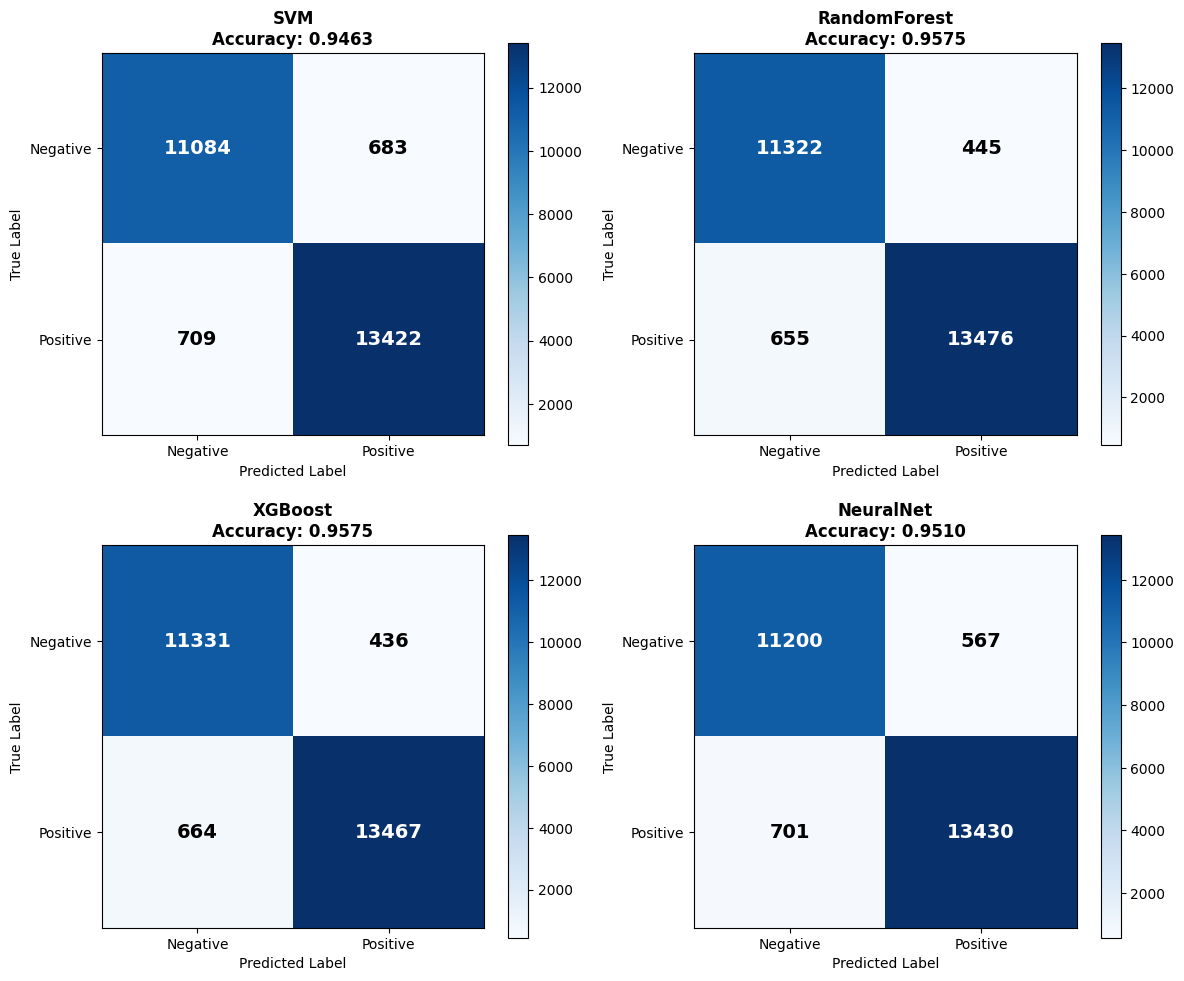

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (name, result) in enumerate(all_models_results.items()):
    cm = result['confusion_matrix']
    im = axes[idx].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    axes[idx].set_title(f'{name}\nAccuracy: {result["accuracy"]:.4f}', 
                        fontsize=12, fontweight='bold')
    
    # Add colorbar
    plt.colorbar(im, ax=axes[idx])
    
    # Add labels
    tick_marks = np.arange(2)
    axes[idx].set_xticks(tick_marks)
    axes[idx].set_yticks(tick_marks)
    axes[idx].set_xticklabels(['Negative', 'Positive'])
    axes[idx].set_yticklabels(['Negative', 'Positive'])
    axes[idx].set_ylabel('True Label', fontsize=10)
    axes[idx].set_xlabel('Predicted Label', fontsize=10)
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(2):
        for j in range(2):
            axes[idx].text(j, i, format(cm[i, j], 'd'),
                          ha="center", va="center",
                          color="white" if cm[i, j] > thresh else "black",
                          fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

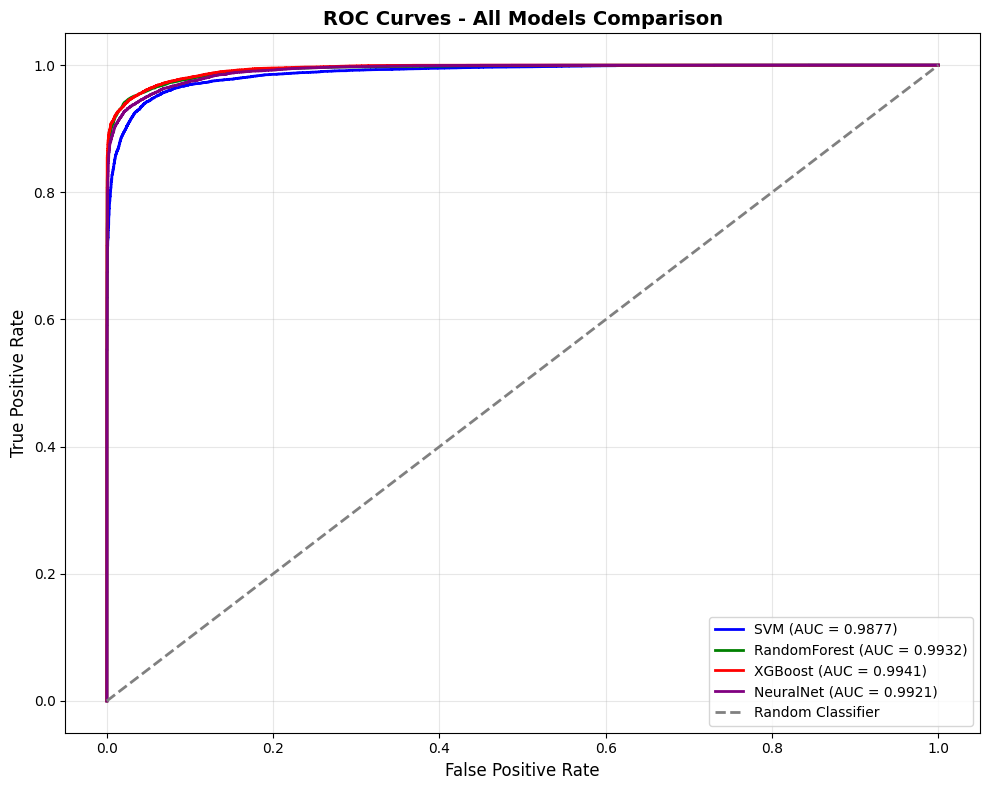

In [64]:
plt.figure(figsize=(10, 8))

colors = ['blue', 'green', 'red', 'purple']
for idx, (name, result) in enumerate(all_models_results.items()):
    plt.plot(result['roc_fpr'], result['roc_tpr'], 
             color=colors[idx], lw=2, 
             label=f'{name} (AUC = {result["auc"]:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random Classifier')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves - All Models Comparison", fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [65]:
os.makedirs('saved_models', exist_ok=True)

print("\n" + "="*70)
print("SAVING ALL MODELS")
print("="*70)

for name, result in all_models_results.items():
    with open(f'saved_models/{name}_model.pkl', 'wb') as f:
        pickle.dump(result['model'], f)
    
    if result['scaler'] is not None:
        with open(f'saved_models/{name}_scaler.pkl', 'wb') as f:
            pickle.dump(result['scaler'], f)
    
    print(f"Saved {name}")

# Save CV results and training times
with open('saved_models/cv_results.pkl', 'wb') as f:
    pickle.dump(results, f)
with open('saved_models/training_times.pkl', 'wb') as f:
    pickle.dump(training_times, f)

# Save the feature scaler used in preprocessing
with open('saved_models/feature_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f"\nAll models saved in './saved_models/' directory")


SAVING ALL MODELS
Saved SVM
Saved RandomForest
Saved XGBoost
Saved NeuralNet

All models saved in './saved_models/' directory


In [66]:
best_model_name = max(results, key=results.get)
print(f"\n{'='*70}")
print(f"BEST MODEL: {best_model_name}")
print(f"CV Accuracy: {results[best_model_name]:.4f}")
print(f"Test Accuracy: {all_models_results[best_model_name]['accuracy']:.4f}")
print(f"AUC: {all_models_results[best_model_name]['auc']:.4f}")
print('='*70)


BEST MODEL: XGBoost
CV Accuracy: 0.9569
Test Accuracy: 0.9575
AUC: 0.9941


In [67]:
comparison_data = []

for name in models.keys():
    comparison_data.append({
        'Model': name,
        'CV Accuracy': f"{results[name]:.4f}",
        'Test Accuracy': f"{all_models_results[name]['accuracy']:.4f}",
        'Test AUC': f"{all_models_results[name]['auc']:.4f}",
        'Precision': f"{all_models_results[name]['precision']:.4f}",
        'Recall': f"{all_models_results[name]['recall']:.4f}",
        'Training Time (s)': f"{all_models_results[name]['training_time']:.2f}",
        'Best': 'YES' if name == best_model_name else ''
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Test Accuracy', ascending=False)

print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)


MODEL PERFORMANCE COMPARISON
       Model CV Accuracy Test Accuracy Test AUC Precision Recall Training Time (s) Best
RandomForest      0.9562        0.9575   0.9932    0.9680 0.9536             35.59     
     XGBoost      0.9569        0.9575   0.9941    0.9686 0.9530              0.36  YES
   NeuralNet      0.9497        0.9510   0.9921    0.9595 0.9504             64.92     
         SVM      0.9444        0.9463   0.9877    0.9516 0.9498           1630.63     


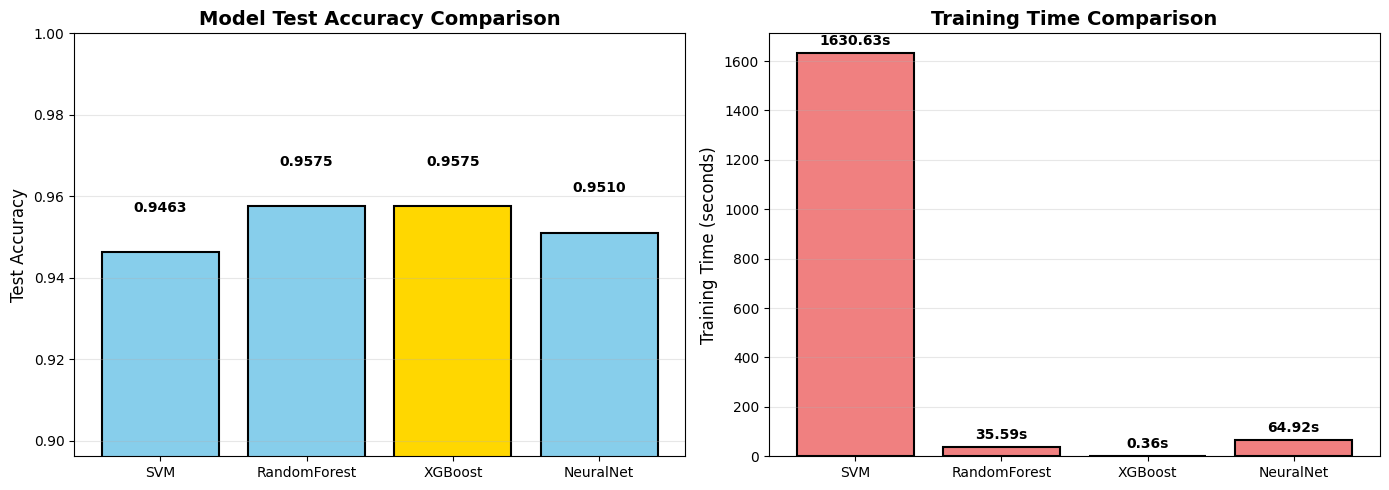

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy Comparison
model_names = list(results.keys())
accuracies = [all_models_results[name]['accuracy'] for name in model_names]
colors = ['gold' if name == best_model_name else 'skyblue' for name in model_names]

bars1 = axes[0].bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Test Accuracy', fontsize=12)
axes[0].set_title('Model Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim([min(accuracies) - 0.05, 1.0])
axes[0].grid(axis='y', alpha=0.3)

for i, (name, acc) in enumerate(zip(model_names, accuracies)):
    axes[0].text(i, acc + 0.01, f'{acc:.4f}', ha='center', fontweight='bold', fontsize=10)

# Plot 2: Training Time Comparison
train_times = [all_models_results[name]['training_time'] for name in model_names]
colors_time = ['gold' if name == best_model_name else 'lightcoral' for name in model_names]

bars2 = axes[1].bar(model_names, train_times, color=colors_time, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Training Time (seconds)', fontsize=12)
axes[1].set_title('Training Time Comparison', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for i, (name, t) in enumerate(zip(model_names, train_times)):
    axes[1].text(i, t + max(train_times)*0.02, f'{t:.2f}s', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [69]:
def load_model(model_name):
    """
    Load a trained model from disk along with its scaler if applicable.
    
    Parameters:
    -----------
    model_name : str
        Name of the model to load ('SVM', 'RandomForest', 'XGBoost', 'NeuralNet')
    
    Returns:
    --------
    model : sklearn model object
        The trained machine learning model
    scaler : StandardScaler or None
        The scaler object if the model requires it (SVM, NeuralNet), None otherwise
    """
    with open(f'saved_models/{model_name}_model.pkl', 'rb') as f:
        model = pickle.load(f)
    
    scaler = None
    scaler_path = f'saved_models/{model_name}_scaler.pkl'
    if os.path.exists(scaler_path):
        with open(scaler_path, 'rb') as f:
            scaler = pickle.load(f)
    
    return model, scaler


def predict_with_loaded_model(model_name, X_new):
    """
    Make predictions using a saved model with proper preprocessing.
    
    Parameters:
    -----------
    model_name : str
        Name of the model to use ('SVM', 'RandomForest', 'XGBoost', 'NeuralNet')
    X_new : array-like or pandas DataFrame
        New data to predict. Must have the same features as training data.
        Should already be preprocessed with MinMaxScaler (for numeric columns).
    
    Returns:
    --------
    predictions : numpy array
        Predicted binary class labels (0 or 1)
    probabilities : numpy array
        Predicted probabilities for each class, shape (n_samples, 2)
    """
    model, scaler = load_model(model_name)
    
    if hasattr(X_new, 'to_numpy'):
        X_new = X_new.to_numpy()
    
    if scaler is not None:
        X_new = scaler.transform(X_new)
    
    predictions = model.predict(X_new)
    probabilities = model.predict_proba(X_new)
    
    return predictions, probabilities


print("\n" + "="*70)
print("Utility functions loaded successfully")
print("="*70)


Utility functions loaded successfully


In [70]:
print("\n" + "="*70)
print("FINAL SUMMARY REPORT")
print("="*70)

print(f"\nDataset Information:")
print(f"{'='*70}")
print(f"Training samples:     {len(X_train)}")
print(f"Test samples:         {len(X_test)}")
print(f"Number of features:   {len(features)}")
print(f"Classification type:  Binary ({classes[0]} vs {classes[1]})")

print(f"\nBest Model: {best_model_name}")
print(f"{'='*70}")
best_result = all_models_results[best_model_name]
print(f"CV Accuracy:          {results[best_model_name]:.4f}")
print(f"Test Accuracy:        {best_result['accuracy']:.4f}")
print(f"Test Precision:       {best_result['precision']:.4f}")
print(f"Test Recall:          {best_result['recall']:.4f}")
print(f"Specificity:          {best_result['specificity']:.4f}")
print(f"AUC Score:            {best_result['auc']:.4f}")
print(f"Training Time:        {best_result['training_time']:.2f}s")

print(f"\nModel Rankings by Test Accuracy:")
print(f"{'='*70}")
accuracy_ranking = sorted(all_models_results.items(), 
                         key=lambda x: x[1]['accuracy'], reverse=True)
for rank, (name, result) in enumerate(accuracy_ranking, 1):
    marker = " <-- BEST" if name == best_model_name else ""
    print(f"  {rank}. {name:15s} {result['accuracy']:.4f}{marker}")

print(f"\nModel Rankings by AUC:")
print(f"{'='*70}")
auc_ranking = sorted(all_models_results.items(), 
                     key=lambda x: x[1]['auc'], reverse=True)
for rank, (name, result) in enumerate(auc_ranking, 1):
    print(f"  {rank}. {name:15s} {result['auc']:.4f}")

print("\n" + "="*70)
print("Pipeline execution completed successfully!")
print("="*70)


FINAL SUMMARY REPORT

Dataset Information:
Training samples:     103589
Test samples:         25898
Number of features:   22
Classification type:  Binary (0 vs 1)

Best Model: XGBoost
CV Accuracy:          0.9569
Test Accuracy:        0.9575
Test Precision:       0.9686
Test Recall:          0.9530
Specificity:          0.9629
AUC Score:            0.9941
Training Time:        0.36s

Model Rankings by Test Accuracy:
  1. RandomForest    0.9575
  2. XGBoost         0.9575 <-- BEST
  3. NeuralNet       0.9510
  4. SVM             0.9463

Model Rankings by AUC:
  1. XGBoost         0.9941
  2. RandomForest    0.9932
  3. NeuralNet       0.9921
  4. SVM             0.9877

Pipeline execution completed successfully!


#### Prescriptive analysis

##### Find importantance of each feature

In [71]:
# Load best model (XGBoost)
best_model, _ = load_model("XGBoost")

print(type(best_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [72]:
# Get booster from trained XGBClassifier
booster = best_model.get_booster()

# Now get feature importance by 'gain'
importance = booster.get_score(importance_type='gain')

# Convert to DataFrame
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

print("Top features by gain:")
print(importance_df.head(10))

Top features by gain:
   Feature  Importance
11     f11  476.760559
6       f6  147.029480
13     f13   78.883827
1       f1   77.106331
0       f0   52.431454
3       f3   48.996452
4       f4   44.576340
7       f7   34.936588
12     f12   32.368370
17     f17   30.125681


In [73]:
# Get actual feature names from training set
feature_names = X_train.columns.tolist()

# Create dictionary mapping f0 -> actual name
feature_mapping = {f"f{i}": name for i, name in enumerate(feature_names)}

print("Feature mapping sample:")
print(list(feature_mapping.items())[:10])

# Replace f0, f1... with actual column names
importance_df['Feature'] = importance_df['Feature'].map(feature_mapping)

print("Top features by gain (with real names):")
print(importance_df.head(10))

Feature mapping sample:
[('f0', 'gender'), ('f1', 'customer_type'), ('f2', 'age'), ('f3', 'travel_type'), ('f4', 'class'), ('f5', 'distance'), ('f6', 'seat_comfort'), ('f7', 'dep_val_time_convenient'), ('f8', 'food_drink'), ('f9', 'gate')]
Top features by gain (with real names):
                    Feature  Importance
11            entertainment  476.760559
6              seat_comfort  147.029480
13   online_booking_service   78.883827
1             customer_type   77.106331
0                    gender   52.431454
3               travel_type   48.996452
4                     class   44.576340
7   dep_val_time_convenient   34.936588
12           online_support   32.368370
17          checkin_service   30.125681


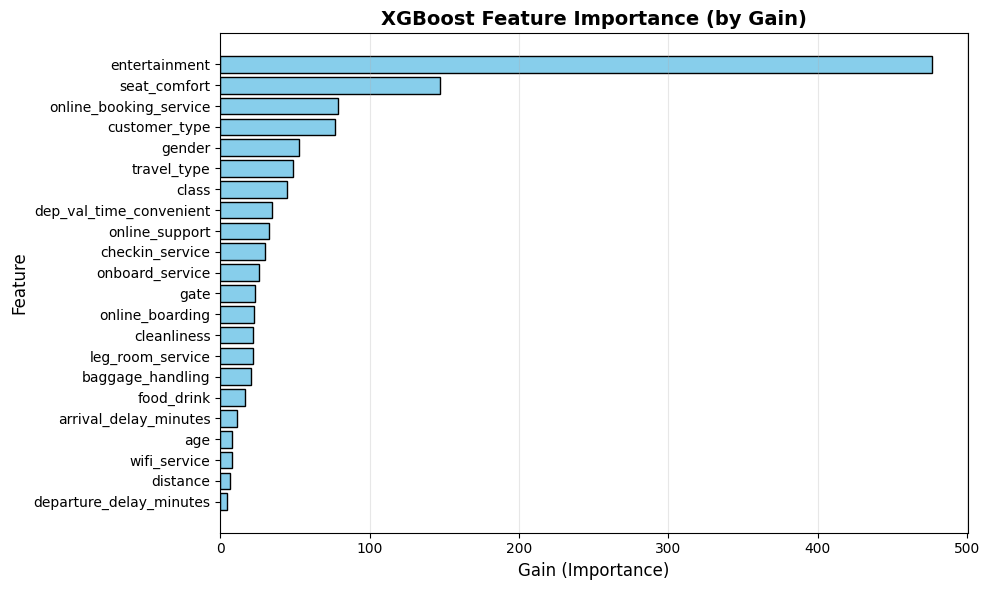

In [74]:
# Sort by importance
importance_df = importance_df.sort_values(by="Importance", ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color="skyblue", edgecolor="black")
plt.xlabel("Gain (Importance)", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.title("XGBoost Feature Importance (by Gain)", fontsize=14, fontweight="bold")
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

#### Optimization Problem

In [75]:
import pulp

Maximize the probability of customer satisfaction by adjusting controllable features. Using model insights estimate the impact of improving each feature (increase in satisfaction probability when the feature improves by one unit)

In [76]:
X = df.drop('satisfaction', axis=1)
actionable_features = ['entertainment', 'seat_comfort', 'online_booking_service', 'food_drink']

impacts = {}
for f in actionable_features:
    baseline = best_model.predict_proba(X)[:, 1]  # Use XGBoost model
    X_new = X.copy()
    X_new[f] = np.minimum(X_new[f] + 1, X_new[f].max())
    new_pred = best_model.predict_proba(X_new)[:, 1]
    impacts[f] = np.mean(new_pred - baseline)

print("Impacts:", impacts)

Impacts: {'entertainment': np.float32(0.031160703), 'seat_comfort': np.float32(0.06680675), 'online_booking_service': np.float32(0.0042792344), 'food_drink': np.float32(-0.0023966683)}


In [77]:
features = list(impacts.keys())
impact = list(impacts.values())
cost = [800000, 800000, 400000, 500000]  # Example costs for each feature and budget in USD
budget = 1500000

In [78]:
prob = pulp.LpProblem("Airline_Satisfaction_Optimization", pulp.LpMaximize)
x = pulp.LpVariable.dicts("Improve", features, cat='Binary')

# Objective: maximize satisfaction improvement
prob += pulp.lpSum([impact[i] * x[features[i]] for i in range(len(features))])

# Budget constraint
prob += pulp.lpSum([cost[i] * x[features[i]] for i in range(len(features))]) <= budget

# Solve
prob.solve()

print("Optimal Service Improvements:")
for f in features:
    if pulp.value(x[f]) == 1:
        print(f)

print("Maximum Satisfaction Improvement:", round(pulp.value(prob.objective), 4))


Optimal Service Improvements:
seat_comfort
online_booking_service
Maximum Satisfaction Improvement: 0.0711
